In [ ]:
!pip install scikit-bio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 50.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.6/58.6 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 56.4 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import r2_score, mean_squared_error


from scipy import stats
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu
from statsmodels.multivariate.manova import MANOVA
from statsmodels.stats.outliers_influence import variance_inflation_factor

from skbio.stats.distance import permanova
from skbio.stats.distance import DistanceMatrix
from scipy.spatial.distance import pdist, squareform

from sklearn.ensemble import IsolationForest

In [ ]:
# Group - 1 data i.e Good = 1
data1 = {
    'Permeability' : [20, 23, 22, 27, 21, 17, 13],
    'LDL_uptake': [1.2, 1.1, 1.4, 1.2, 1.8, 1.3, 1.7],
    'Total_ROS': [1, 0.9, 1.1, 1.2, 0.8, 0.9, 0.7],
    'Vascular_Marker' : [100, 98, 96, 90, 92, 96, 100],
    'Cell_Signalling': [80, 78, 85, 89, 95, 88, 92],
    'Tube_formation': [100, 98, 99, 90, 96, 92, 97],
    'In_vivo_recovery': [70, 78, 79, 83, 82, 72, 71],
    'Group': [1]*7                                        # 1 is Good
}

In [ ]:
# Group - 2 data i.e. Bad = 0
data2 = {
    'Permeability' : [67, 69, 71, 75, 68, 79, 70],
    'LDL_uptake': [0.3, 2, 0.3, 0.22, 0.34, 0.19, 0.35],
    'Total_ROS': [1.9, 2.2, 1.8, 2, 1.9, 1.8, 2.1],
    'Vascular_Marker' : [77, 74, 68, 81, 75, 70, 69],
    'Cell_Signalling': [50, 55, 43, 49, 47, 43, 59],
    'Tube_formation': [40, 44, 39, 32, 35, 41, 46],
    'In_vivo_recovery': [25, 19, 35, 32, 34, 28, 22],
    'Group': [0]*7                                      # 0 is Bad
}

In [ ]:
df1 = pd.DataFrame(data1)

In [ ]:
df1

,Permeability,LDL_uptake,Total_ROS,Vascular_Marker,Cell_Signalling,Tube_formation,In_vivo_recovery,Group
0,20,1.2,1.0,100,80,100,70,1
1,23,1.1,0.9,98,78,98,78,1
2,22,1.4,1.1,96,85,99,79,1
3,27,1.2,1.2,90,89,90,83,1
4,21,1.8,0.8,92,95,96,82,1
5,17,1.3,0.9,96,88,92,72,1
6,13,1.7,0.7,100,92,97,71,1


In [ ]:
df2 = pd.DataFrame(data2)

In [ ]:
df2

,Permeability,LDL_uptake,Total_ROS,Vascular_Marker,Cell_Signalling,Tube_formation,In_vivo_recovery,Group
0,67,0.30,1.9,77,50,40,25,0
1,69,2.00,2.2,74,55,44,19,0
2,71,0.30,1.8,68,43,39,35,0
3,75,0.22,2.0,81,49,32,32,0
4,68,0.34,1.9,75,47,35,34,0
5,79,0.19,1.8,70,43,41,28,0
6,70,0.35,2.1,69,59,46,22,0


In [ ]:
# Combining Group 1 & 2
df = pd.concat([df1, df2], axis=0, ignore_index=True)

In [ ]:
# Check Duplicate row in dataset
df.duplicated().sum()

np.int64(0)

In [ ]:
df

,Permeability,LDL_uptake,Total_ROS,Vascular_Marker,Cell_Signalling,Tube_formation,In_vivo_recovery,Group
0,20,1.20,1.0,100,80,100,70,1
1,23,1.10,0.9,98,78,98,78,1
2,22,1.40,1.1,96,85,99,79,1
3,27,1.20,1.2,90,89,90,83,1
4,21,1.80,0.8,92,95,96,82,1
5,17,1.30,0.9,96,88,92,72,1
6,13,1.70,0.7,100,92,97,71,1
7,67,0.30,1.9,77,50,40,25,0
8,69,2.00,2.2,74,55,44,19,0
9,71,0.30,1.8,68,43,39,35,0


In [ ]:
# Shuffle original dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
df

,Permeability,LDL_uptake,Total_ROS,Vascular_Marker,Cell_Signalling,Tube_formation,In_vivo_recovery,Group
0,71,0.30,1.8,68,43,39,35,0
1,68,0.34,1.9,75,47,35,34,0
2,20,1.20,1.0,100,80,100,70,1
3,79,0.19,1.8,70,43,41,28,0
4,17,1.30,0.9,96,88,92,72,1
5,69,2.00,2.2,74,55,44,19,0
6,22,1.40,1.1,96,85,99,79,1
7,23,1.10,0.9,98,78,98,78,1
8,70,0.35,2.1,69,59,46,22,0
9,21,1.80,0.8,92,95,96,82,1


In [ ]:
# Descriptive Statistics
df.describe()

,Permeability,LDL_uptake,Total_ROS,Vascular_Marker,Cell_Signalling,Tube_formation,In_vivo_recovery,Group
count,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000
mean,45.857143,0.957143,1.450000,84.714286,68.071429,67.785714,52.142857,0.500000
std,26.720367,0.653210,0.548775,12.418526,20.200778,29.571760,25.806550,0.518875
min,13.000000,0.190000,0.700000,68.000000,43.000000,32.000000,19.000000,0.000000
25%,21.250000,0.310000,0.925000,74.250000,49.250000,40.250000,29.000000,0.000000
50%,47.000000,1.150000,1.500000,85.500000,68.500000,68.000000,52.500000,0.500000
75%,69.750000,1.375000,1.900000,96.000000,87.250000,96.750000,76.500000,1.000000
max,79.000000,2.000000,2.200000,100.000000,95.000000,100.000000,83.000000,1.000000


In [ ]:
# Group Wise Descriptive Statistics for each feature
for col in df.columns[:-1]:
    print(f"Descriptive Statistics for {col}:")
    group_stats = df.groupby("Group")[col].describe()
    print(group_stats)
    print("\n")

Descriptive Statistics for Permeability:
       count       mean       std   min   25%   50%   75%   max
Group                                                          
0        7.0  71.285714  4.270608  67.0  68.5  70.0  73.0  79.0
1        7.0  20.428571  4.466809  13.0  18.5  21.0  22.5  27.0


Descriptive Statistics for LDL_uptake:
       count      mean       std   min   25%  50%    75%  max
Group                                                        
0        7.0  0.528571  0.651522  0.19  0.26  0.3  0.345  2.0
1        7.0  1.385714  0.267261  1.10  1.20  1.3  1.550  1.8


Descriptive Statistics for Total_ROS:
       count      mean       std  min   25%  50%   75%  max
Group                                                      
0        7.0  1.957143  0.151186  1.8  1.85  1.9  2.05  2.2
1        7.0  0.942857  0.171825  0.7  0.85  0.9  1.05  1.2


Descriptive Statistics for Vascular_Marker:
       count       mean       std   min   25%   50%   75%    max
Group                  

# Statistical Modelling

### 1). t-Test:
A t-test is performed to determine whether each feature differs significantly between the healthy and diabetic groups. A p-value < 0.05 indicates a statistically significant difference between the two groups. These results confirm that diabetes significantly alters vascular cell function across the measured features.
#####-> Compares the means of two groups
#####-> Assumes data is normally distributed and variances are similar
#####-> Best for large samples with normal data

In [ ]:
# Independent t-test for each feature
features = df.columns[:-1]

for feature in features:
    group1 = df[df["Group"] == 1][feature]
    group0 = df[df["Group"] == 0][feature]

    t_stat, p_value = ttest_ind(group1, group0, equal_var=False)

    print(f"{feature} Difference: t = {t_stat:.2f}, p = {p_value:.6f}")

    # Interpretation
    if p_value < 0.05:
        print(f"Significant difference in {feature} between Group 1 and Group 0.\n")
    else:
        print(f"No significant difference in {feature} between Group 1 and Group 0.\n")

Permeability Difference: t = -21.77, p = 0.000000
Significant difference in Permeability between Group 1 and Group 0.

LDL_uptake Difference: t = 3.22, p = 0.012307
Significant difference in LDL_uptake between Group 1 and Group 0.

Total_ROS Difference: t = -11.73, p = 0.000000
Significant difference in Total_ROS between Group 1 and Group 0.

Vascular_Marker Difference: t = 9.82, p = 0.000001
Significant difference in Vascular_Marker between Group 1 and Group 0.

Cell_Signalling Difference: t = 11.53, p = 0.000000
Significant difference in Cell_Signalling between Group 1 and Group 0.

Tube_formation Difference: t = 24.45, p = 0.000000
Significant difference in Tube_formation between Group 1 and Group 0.

In_vivo_recovery Difference: t = 15.73, p = 0.000000
Significant difference in In_vivo_recovery between Group 1 and Group 0.



## 2). Mann–Whitney U Test
A Mann–Whitney U test was performed to determine whether each feature differs significantly between the healthy and diabetic groups. A p-value < 0.05 indicates a statistically significant difference between the two groups. This non-parametric test was chosen due to the small sample size and non-normal data distribution. The results confirm that diabetes significantly alters vascular cell function across the measured features.
##### -> Compares the distributions / medians of two groups
##### -> Does not assume normality
##### -> Best for small samples, skewed data, or presence of outliers

In [ ]:
# Perform Mann–Whitney U test for each feature
features = df.columns[:-1]

for feature in features:
    group0 = df[df["Group"] == 0][feature]
    group1 = df[df["Group"] == 1][feature]

    u_stat, p_val = mannwhitneyu(group0, group1, alternative='two-sided')

    print(f"{feature}: U = {u_stat:.2f}, p = {p_val:.4f}")

Permeability: U = 49.00, p = 0.0006
LDL_uptake: U = 7.00, p = 0.0295
Total_ROS: U = 49.00, p = 0.0021
Vascular_Marker: U = 0.00, p = 0.0021
Cell_Signalling: U = 0.00, p = 0.0021
Tube_formation: U = 0.00, p = 0.0006
In_vivo_recovery: U = 0.00, p = 0.0006


In [ ]:
# The Mann–Whitney U test shows that all measured biological features are significantly different
# between Group 0 and Group 1 (p < 0.05). This indicates a clear and consistent separation between the two groups across all features.

## 3). MANOVA Test
##### MANOVA is a parametric statistical test used to determine whether two or more groups differ significantly across multiple continuous dependent variables at the same time.
##### It evaluates group differences by comparing the multivariate means while accounting for correlations between variables.
##### A small Wilks’ Lambda or a large Pillai’s Trace, along with a p-value less than the chosen significance level (typically 0.05), indicates that the combined dependent variables differ significantly between groups.

In [ ]:
# MANOVA model
manova = MANOVA.from_formula(
    'Permeability + LDL_uptake + Total_ROS + Vascular_Marker + Cell_Signalling + Tube_formation + In_vivo_recovery ~ Group',
    data=df
)

# Print results
print(manova.mv_test())

                   Multivariate linear model
                                                                
----------------------------------------------------------------
       Intercept          Value   Num DF Den DF  F Value  Pr > F
----------------------------------------------------------------
          Wilks' lambda    0.0006 7.0000 6.0000 1400.1613 0.0000
         Pillai's trace    0.9994 7.0000 6.0000 1400.1613 0.0000
 Hotelling-Lawley trace 1633.5215 7.0000 6.0000 1400.1613 0.0000
    Roy's greatest root 1633.5215 7.0000 6.0000 1400.1613 0.0000
----------------------------------------------------------------
                                                                
----------------------------------------------------------------
           Group           Value   Num DF Den DF F Value  Pr > F
----------------------------------------------------------------
            Wilks' lambda   0.0022 7.0000 6.0000 391.4482 0.0000
           Pillai's trace   0.9978 7.0000 6.0

In [ ]:
# The very small Wilks’ lambda (≈ 0) indicates strong separation between the two groups.
# The extremely low p-value shows this difference is statistically significant.
# This means the overall biological profile, considering all seven features together, is significantly different between Group 0 and Group 1.

# PERMANOVA Test:
##### PERMANOVA (Permutational Multivariate Analysis of Variance) is a non-parametric statistical test used to determine whether two or more groups differ significantly across multiple variables simultaneously.
##### PERMANOVA determines group differences by comparing the average distances between samples from different groups to the average distances within the same group. This comparison produces a pseudo-F statistic, where larger values indicate stronger group separation.
##### If p < 0.05, there is a statistically significant multivariate difference between the groups.

In [ ]:
# DataFrame (df) assumed already created
features = [
    "Permeability", "LDL_uptake", "Total_ROS",
    "Vascular_Marker", "Cell_Signalling",
    "Tube_formation", "In_vivo_recovery"
]

# Distance matrix (Euclidean)
X = df[features].values
dist_matrix = squareform(pdist(X, metric="euclidean"))
dm = DistanceMatrix(dist_matrix)

# Group labels
groups = df["Group"].values

# PERMANOVA
result = permanova(distance_matrix=dm, grouping=groups, permutations=999)
print(result)

method name                PERMANOVA
test statistic name         pseudo-F
sample size                       14
number of groups                   2
test statistic            277.622765
p-value                        0.002
number of permutations           999
Name: PERMANOVA results, dtype: object


In [ ]:
# This very large test statistic value indicates that between-group differences are much larger than within-group differences, suggesting strong separation between groups.
# Because the permutation-based p-value is below 0.05, PERMANOVA confirms a statistically significant difference between the groups.

## Scatter Plot
A scatter plot shows the relationship between two numerical variables using individual data points on an X–Y graph.

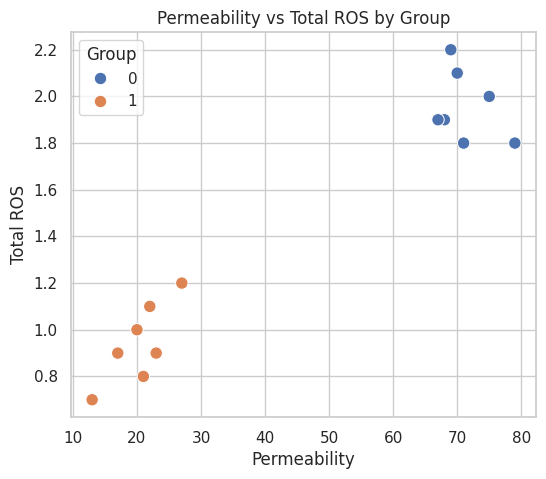

In [ ]:
# Scatter Plot for Permeability & Total ROS
plt.figure(figsize=(6,5))

sns.scatterplot(data=df, x="Permeability", y="Total_ROS", hue="Group", s=80)

plt.xlabel("Permeability")
plt.ylabel("Total ROS")
plt.title("Permeability vs Total ROS by Group")
plt.legend(title="Group")
plt.show()

## Histogram PLot
To visualize the distribution of each feature in the dataset individually

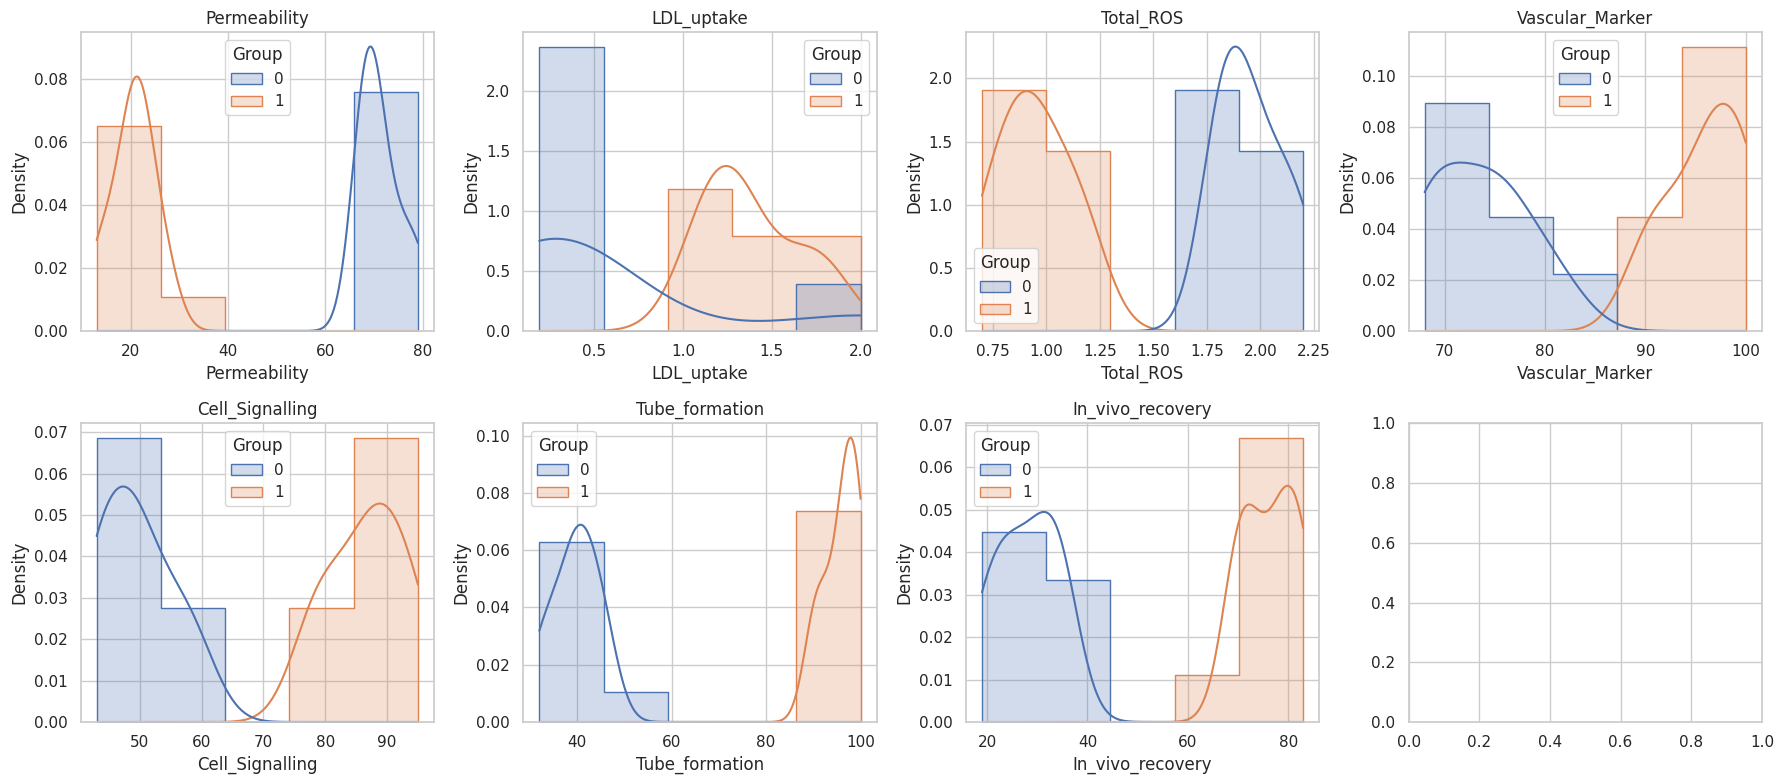

In [ ]:
features = df.drop(columns=["Group"]).columns

# Create 2x4 subplot grid
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

# Plot each feature in a subplot
for i, feature in enumerate(features):
    sns.histplot(data=df, x=feature, hue="Group", kde=True, stat="density", common_norm=False, element="step", ax=axes[i])

    axes[i].set_title(f"{feature}")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Density")

plt.tight_layout()
plt.show()

In [ ]:
# The Histogram plots show minimal overlap between the two groups in almost all features.
# This suggests that the features are highly discriminative, likely leading to a model with high accuracy and distinct decision boundaries.

##### Outlier Ditection using Boxplot

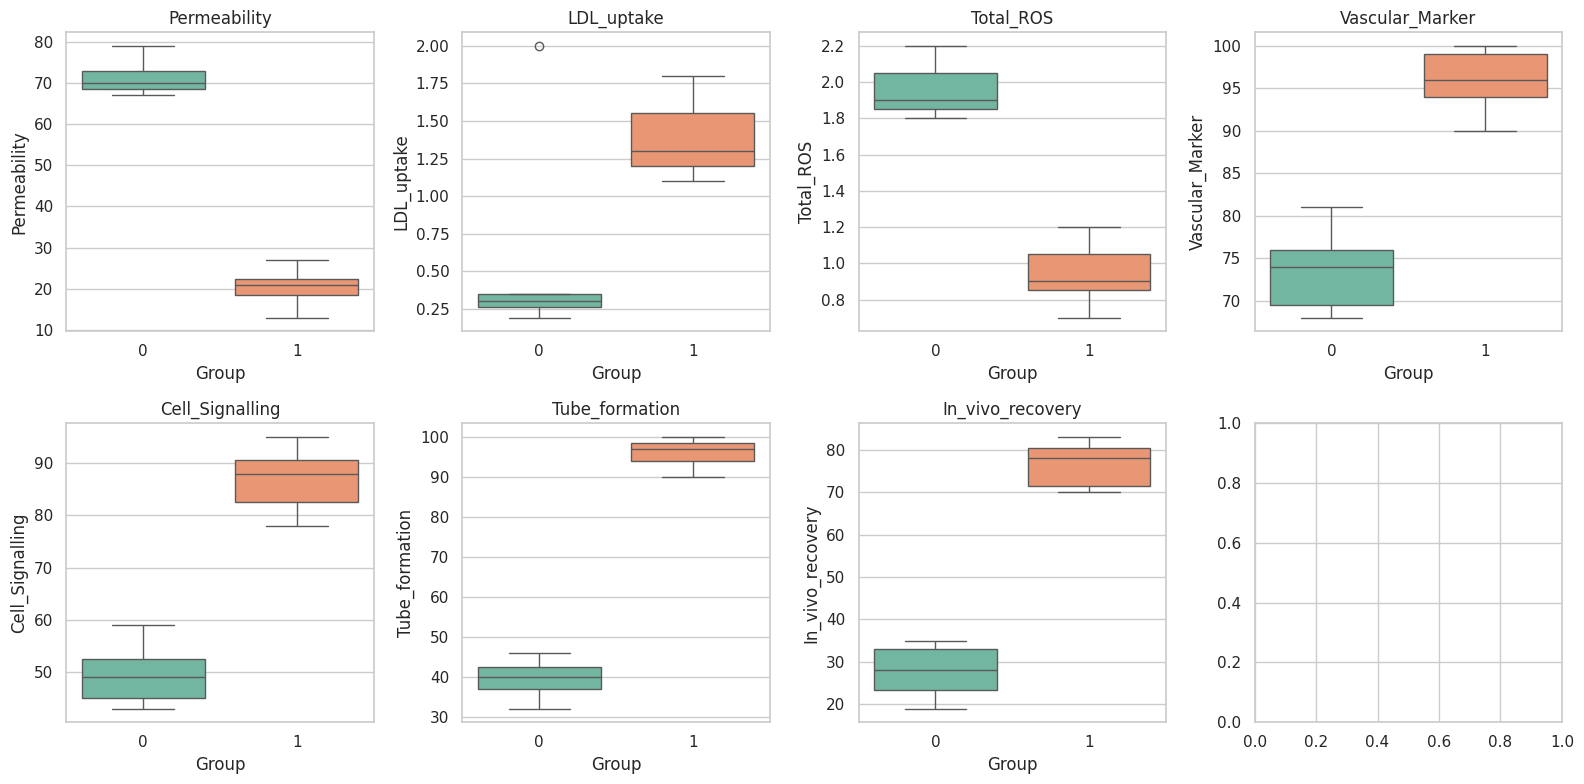

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(data=df, x="Group", y=feature, hue="Group", palette="Set2", legend=False, ax=axes[i])
    axes[i].set_title(feature)

plt.tight_layout()
plt.show()

In [ ]:
# One outlier was observed in LDL uptake for Group 0. This indicates that one sample behaved differently.
# However, the overall distribution still shows a clear separation between Group 0 and Group 1.

## Pair Plot
To visualize the distribution and pairwise relationships (scatter) between multiple features together

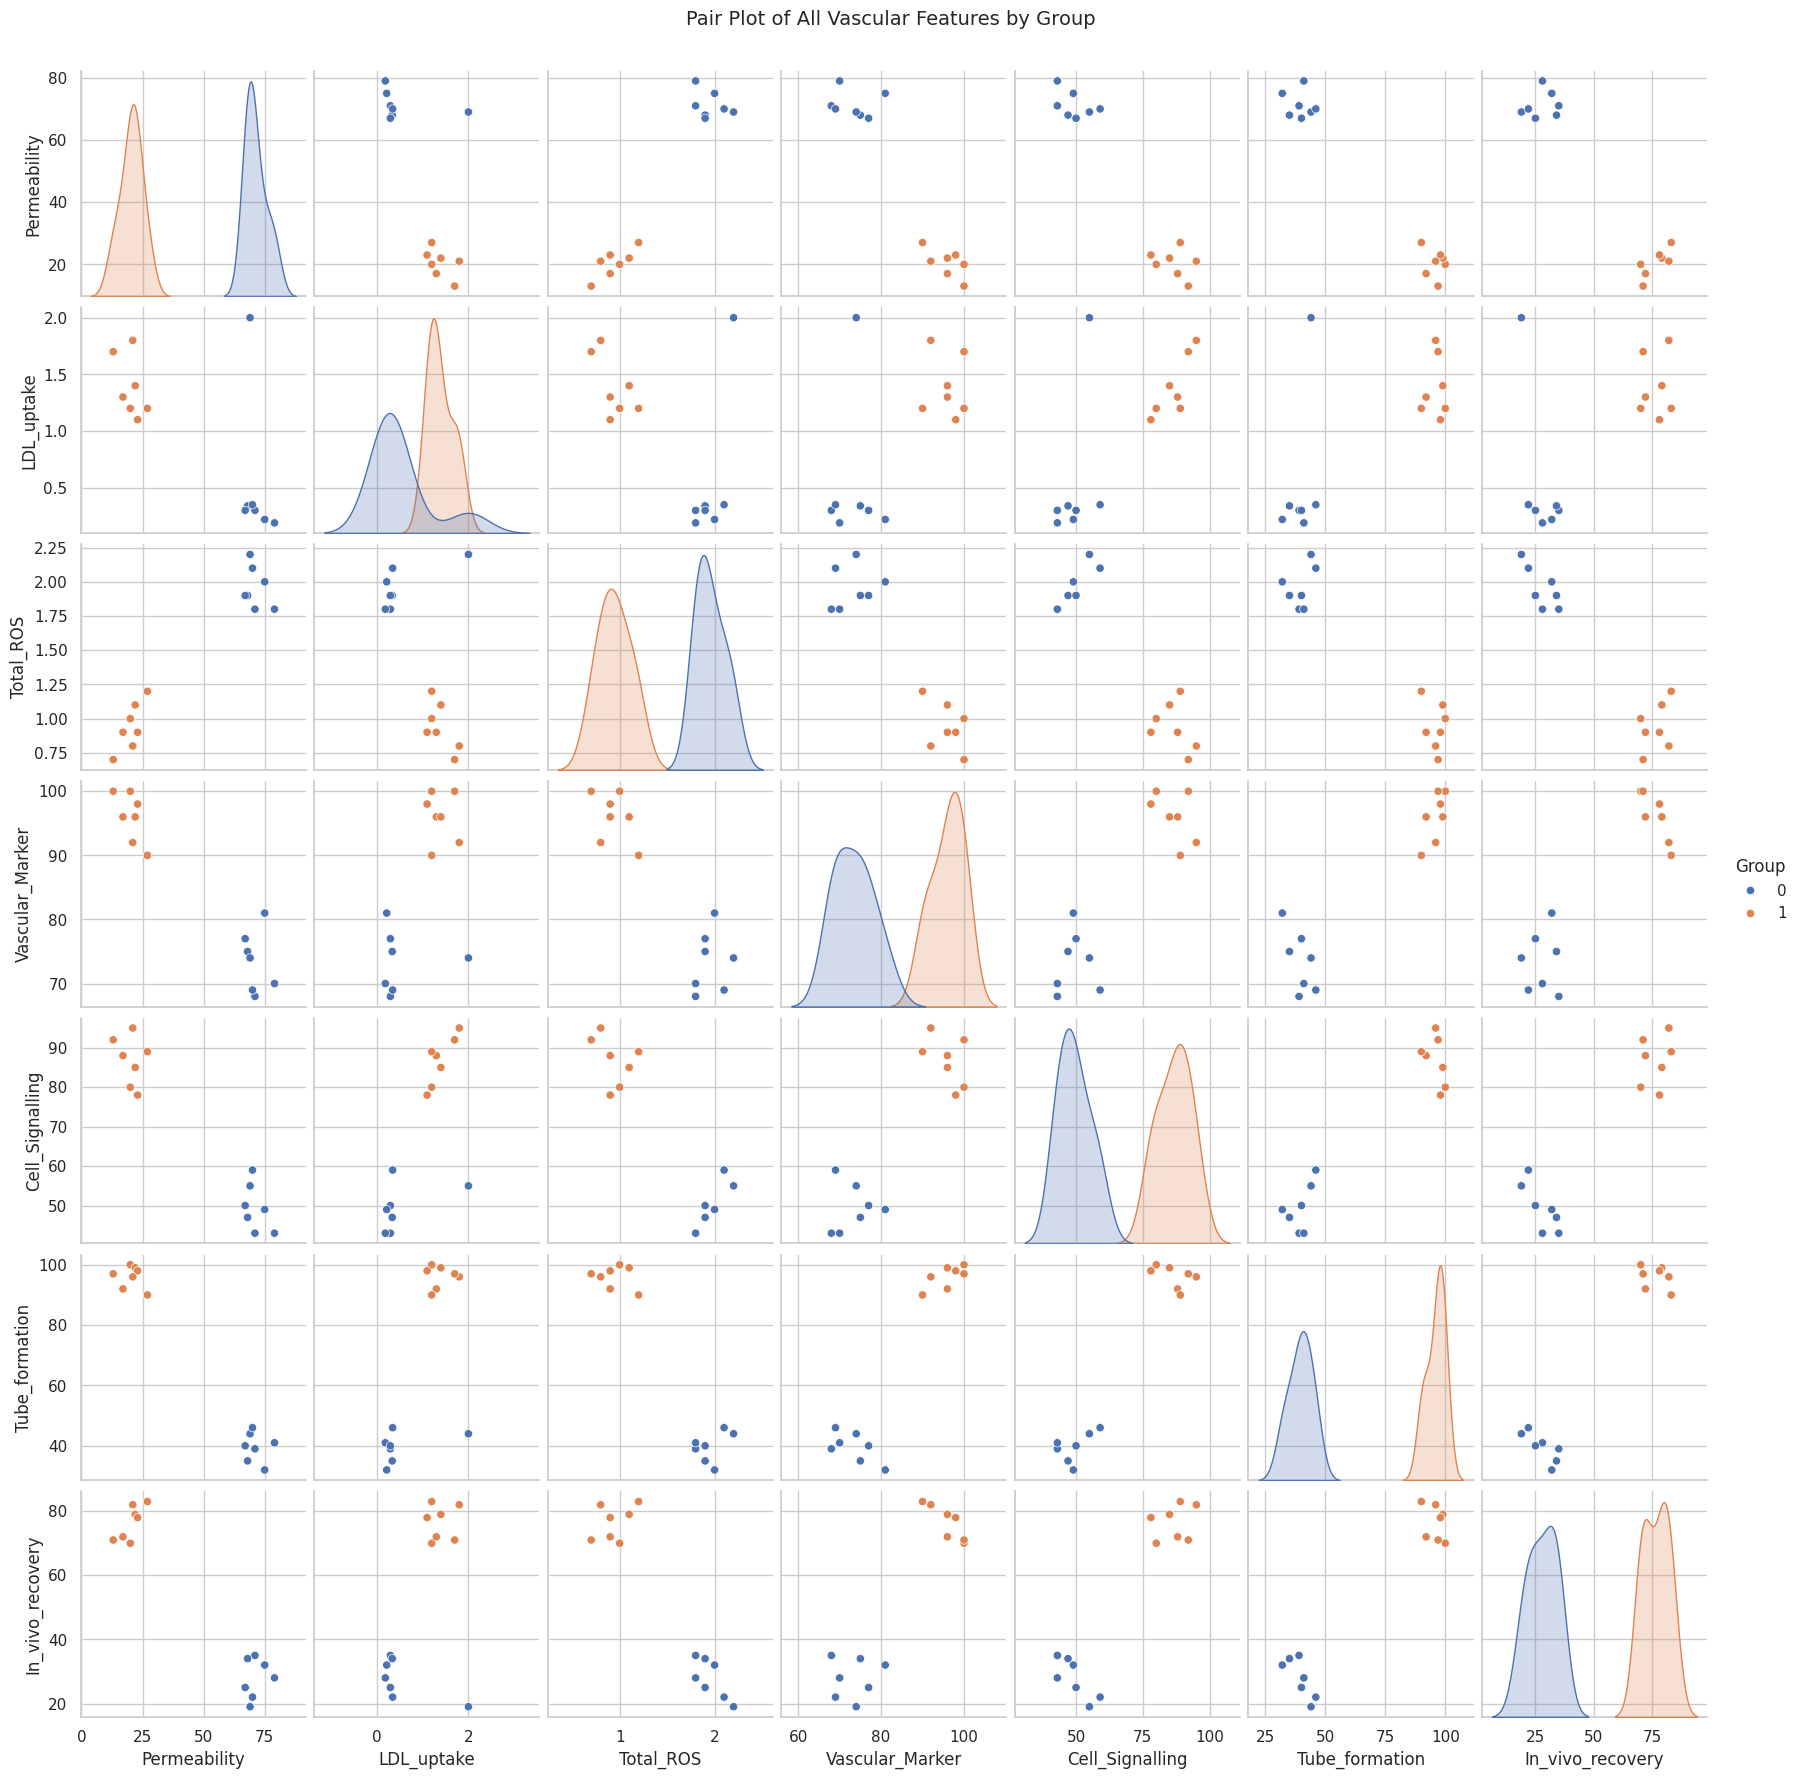

In [ ]:
# Set style for better visuals
sns.set(style="whitegrid")

# Create the pair plot
pair_plot = sns.pairplot(df, hue="Group", diag_kind="kde", height=2.5)

# Add a title
pair_plot.fig.suptitle("Pair Plot of All Vascular Features by Group", y=1.02, fontsize=14)

plt.show()

In [ ]:
# In every scatterplot, the two groups form clearly separated clusters with no overlap,
# showing that Group 0 and Group 1 are perfectly distinguishable in all feature combinations.
# The clear gap between the blue and orange clusters shows that the two groups are linearly separable,
# meaning simple models like Logistic Regression or a Linear SVM can classify them with near-perfect accuracy without needing complex kernels.

### **Correlation HeatMap**
A correlation heatmap visualizes how strongly each feature is related to another using the correlation coefficient (r).
##### Values range from -1 to +1
##### 🔵 Dark Blue (~ +1) → indicates a perfect positive linear relationship (as one variable increases, so does the other).
##### 🔴 Dark Red (~ -1) → indicates a perfect negative linear relationship (as one increases, the other decreases).
##### ⚪ White (~ 0) → means there’s no linear relationship between the variables.

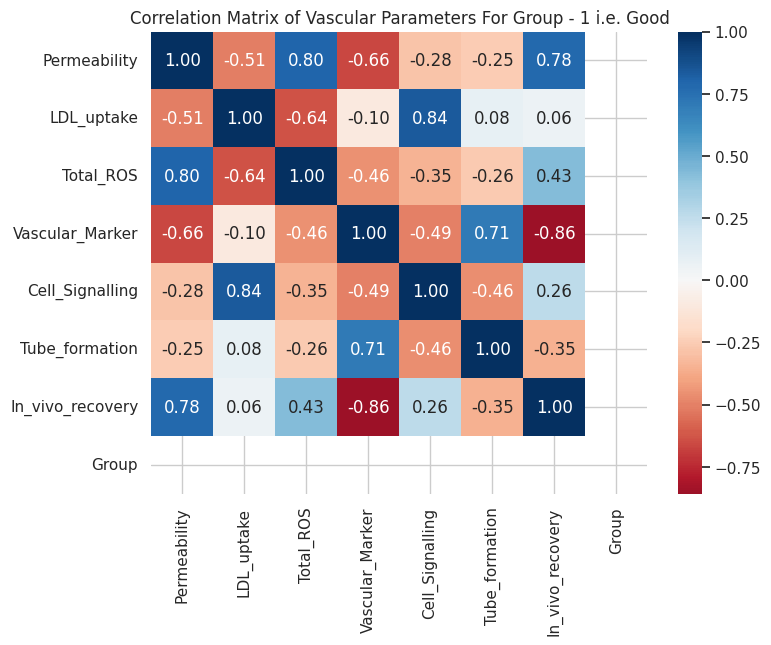

In [ ]:
# Correlation Heatmap for Group - 1 i.e. Good = 1
corr_matrix1 = df1.corr()

# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix1, annot=True, fmt=".2f", cmap="RdBu", center=0)
plt.title("Correlation Matrix of Vascular Parameters For Group - 1 i.e. Good")
plt.show()

In [ ]:
# Permeability ↔ Total ROS (0.80)
#    → When oxidative stress (ROS) increases, permeability also increases.
#    → This means cells become leakier when ROS is high, even in the good group.
# LDL Uptake ↔ Cell Signalling (0.84)
#    → Higher LDL uptake is strongly linked with increased cell-signalling activity.
# Vascular Marker ↔ Tube Formation (0.71)
#    → When endothelial markers are high, the cells form better tube networks, indicating good angiogenesis.
# Permeability ↔ Vascular Marker (−0.66)
#    → When vascular markers increase, permeability decreases.
#    → This means better endothelial integrity is linked to lower leakage.
# Vascular Marker ↔ In-vivo Recovery (−0.86)
#    → This is the strongest negative correlation in the entire matrix.
#    → Even in the 'Good' group, some markers (Vascular Marker) behave opposite to recovery.
#    → So another feature is impacting in-vivo recovery more strongly.
# This is biologically surprising — but mathematically correct.

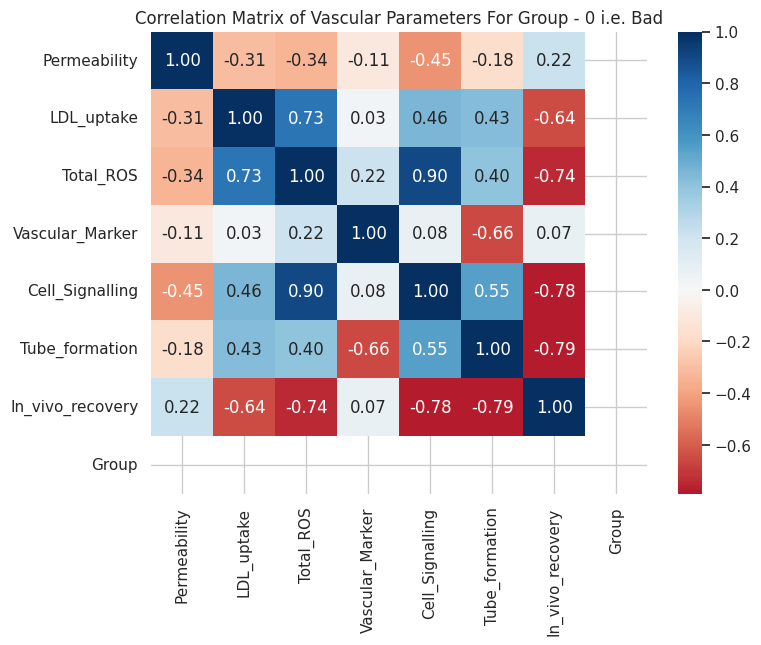

In [ ]:
# Correlation Heatmap for Group - 0 i.e. bad
corr_matrix2 = df2.corr()

# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix2, annot=True, fmt=".2f", cmap="RdBu", center=0)
plt.title("Correlation Matrix of Vascular Parameters For Group - 0 i.e. Bad")
plt.show()

In [ ]:
# In-Vivo Recovery ↔ Total ROS (−0.74)
#    → High oxidative stress = poor recovery
# In-Vivo Recovery ↔ Cell Signalling (−0.78)
#    → High Cell Signalling = poor recovery
# In-Vivo Recovery ↔ Tube Formation (−0.79)
#    → High Tube Formation = poor recovery
# In-Vivo Recovery ↔ LDL Uptake (−0.64)
#    → High LDL Uptake  = poor recovery
# Cell Signalling ↔ Total ROS (0.90)
#    → signalling is high when ROS is high
# LDL Uptake ↔ Total ROS (0.73)
#    → Higher oxidative stress occurs alongside increased LDL uptake
# Vascular Marker ↔ Tube Formation (−0.66)
#    → Higher vascular marker expression = poor tube formation
# In disease states, the body often creates "leaky" or disorganized blood vessels.
# These vessels are poor quality and actually worsen the condition.
# The fact that Vascular_Marker is negatively correlated with Tube_formation (-0.66) confirms this—lots of tubes are forming,
# but they lack the proper markers of healthy vessels.

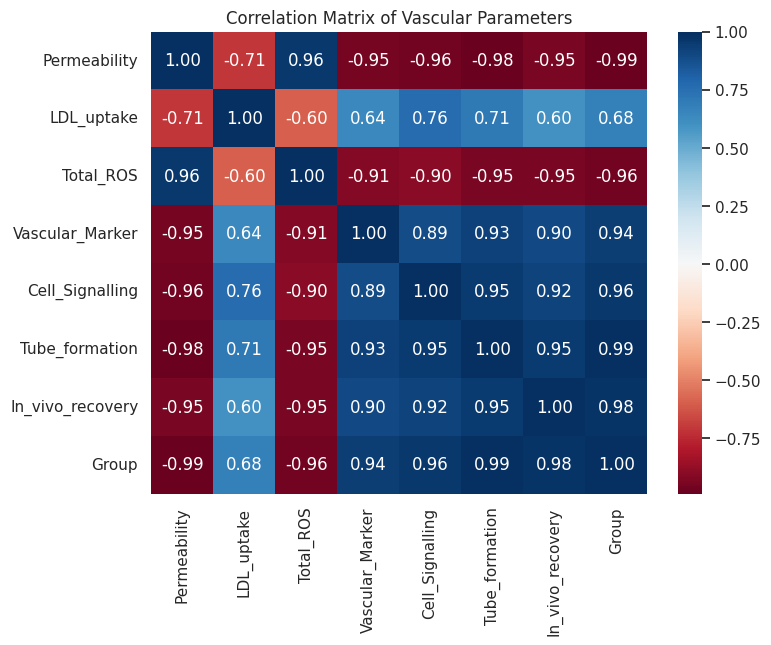

In [ ]:
corr_matrix = df.corr()

# Correlation Heatmap For Combined Dataset
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu", center=0)
plt.title("Correlation Matrix of Vascular Parameters")
plt.show()

In [ ]:
# Cell signalling ↔ Tube formation = 0.95
# Cell signalling ↔ Vascular marker = 0.89
# Tube formation ↔ In vivo recovery = 0.95
# Vascular marker ↔ In vivo recovery = 0.90
# This means, When one marker increases, the other marker also increases. When one decreases, the other also decreases.

# ROS ↔ Cell signalling = −0.90
# ROS ↔ Tube Formation = −0.95
# ROS ↔ Recovery = −0.95
# Higher ROS = poorer function across all markers and recovery

# Anomaly Detection For original Dataset
##### Anomaly detection is the process of finding data points that behave very differently from the rest.

##### 1). Z-Score Method : It assumes the data follows a normal distribution. And marks values that are more than 3 standard deviations away from the mean.


In [ ]:
X = df.drop(columns=['Group',], axis=1)
y = df['Group']

In [ ]:
X

,Permeability,LDL_uptake,Total_ROS,Vascular_Marker,Cell_Signalling,Tube_formation,In_vivo_recovery
0,71,0.30,1.8,68,43,39,35
1,68,0.34,1.9,75,47,35,34
2,20,1.20,1.0,100,80,100,70
3,79,0.19,1.8,70,43,41,28
4,17,1.30,0.9,96,88,92,72
5,69,2.00,2.2,74,55,44,19
6,22,1.40,1.1,96,85,99,79
7,23,1.10,0.9,98,78,98,78
8,70,0.35,2.1,69,59,46,22
9,21,1.80,0.8,92,95,96,82


In [ ]:
y

,Group
0,0
1,0
2,1
3,0
4,1
5,0
6,1
7,1
8,0
9,1


In [ ]:
# Z-Score Outlier Detection
z_scores = np.abs(stats.zscore(X))
df["Anomaly_Z"] = (z_scores > 3).any(axis=1).astype(int)
anomalies_Z = df[df["Anomaly_Z"] == 1]

In [ ]:
anomalies_Z

,Permeability,LDL_uptake,Total_ROS,Vascular_Marker,Cell_Signalling,Tube_formation,In_vivo_recovery,Group,Anomaly_Z


In [ ]:
pd.crosstab(df["Group"], df["Anomaly_Z"])

Anomaly_Z,0
Group,
0,7
1,7


##### 2). IQR Outlier Detection : In this values below Q1 - 1.5 x IQR  or above Q3 + 1.5 x IQR are treated as outliers.

In [ ]:
# IQR Outlier Detection
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)

IQR = Q3 - Q1

In [ ]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [ ]:
iqr_outliers = ((X < lower_bound) | (X > upper_bound))
df["Anomaly_IQR"] = iqr_outliers.any(axis=1).astype(int)
anomalies_IQR = df[df["Anomaly_IQR"] == 1]

In [ ]:
anomalies_IQR

,Permeability,LDL_uptake,Total_ROS,Vascular_Marker,Cell_Signalling,Tube_formation,In_vivo_recovery,Group,Anomaly_Z,Anomaly_IQR


In [ ]:
pd.crosstab(df["Group"], df["Anomaly_IQR"])

Anomaly_IQR,0
Group,
0,7
1,7


In [ ]:
iqr_outliers.sum()

,0
Permeability,0
LDL_uptake,0
Total_ROS,0
Vascular_Marker,0
Cell_Signalling,0
Tube_formation,0
In_vivo_recovery,0


##### 3). Isolation Forest (Machine Learning-Based): An unsupervised learning model that isolates anomalies based on feature distributions.
##### Isolation Forest detects anomalies by isolating points using random cuts; anomalies require fewer cuts, so they have shorter path lengths.
##### If Z-Score/IQR flag outliers, those scores may be extreme values (e.g., > 95% healing or < 10% healing).
##### If Isolation Forest flags an outlier, it suggests anomalous healing behavior based on the full dataset.

In [ ]:
# Isolation Forest
iso = IsolationForest(n_estimators=200, contamination=0.05, random_state=42)

In [ ]:
# Scale the Data (Standardization)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X_scaled

array([[ 0.97648269, -1.04399688,  0.66186007, -1.39672248, -1.28796283,
        -1.01016467, -0.68935924],
       [ 0.85997055, -0.98044924,  0.85096294, -0.81177033, -1.08247588,
        -1.15053494, -0.72957186],
       [-1.00422367,  0.38582493, -0.85096294,  1.27734449,  0.61279143,
         1.13048205,  0.71808254],
       [ 1.28718172, -1.21875288,  0.66186007, -1.2295933 , -1.28796283,
        -0.93997953, -0.97084759],
       [-1.12073581,  0.54469402, -1.04006582,  0.94308612,  1.02376532,
         0.84974149,  0.79850778],
       [ 0.89880793,  1.65677766,  1.41827157, -0.89533492, -0.67150199,
        -0.83470182, -1.33276119],
       [-0.92654891,  0.70356311, -0.66186007,  0.94308612,  0.86965011,
         1.09538948,  1.07999614],
       [-0.88771153,  0.22695584, -1.04006582,  1.11021531,  0.51004796,
         1.06029691,  1.03978352],
       [ 0.93764531, -0.96456233,  1.2291687 , -1.31315789, -0.46601504,
        -0.76451668, -1.21212332],
       [-0.96538629,  1.3390

In [ ]:
df["Anomaly_IF"] = iso.fit_predict(X_scaled)

In [ ]:
df["Anomaly_IF"].value_counts()

,count
Anomaly_IF,
1,13
-1,1


In [ ]:
df["Anomaly_IF"] = df["Anomaly_IF"].map({1: 0, -1: 1})

In [ ]:
anomalies_IF = df[df["Anomaly_IF"] == 1]

In [ ]:
anomalies_IF

,Permeability,LDL_uptake,Total_ROS,Vascular_Marker,Cell_Signalling,Tube_formation,In_vivo_recovery,Group,Anomaly_Z,Anomaly_IQR,Anomaly_IF
5,69,2.0,2.2,74,55,44,19,0,0,0,1


In [ ]:
pd.crosstab(df["Group"], df["Anomaly_IF"])

Anomaly_IF,0,1
Group,,
0,6,1
1,7,0


In [ ]:
# Z-score and IQR look only at distance from the mean or quartiles
# They only detect points that are numerically extreme (very high or very low).
# But Isolation Forest detects behavioral anomalies based on pattern differences, not just extreme values.

### **Multicollinearity**
##### Multicollinearity occurs when two or more independent variables (features) in a dataset are highly correlated with each other.
##### Multicollinearity does not reduce accuracy directly, but it damages interpretation and stability of the model.
##### To detect we use Variance Inflation Factor (VIF) test.
##### if VIF ≈ 1 → No Multicollinearity
##### if 1 < VIF <= 5 → Low Multicollinearity
##### if 5 < VIF <= 10 → Moderate Multicollinearity
##### if VIF > 10 → High Multicollinearity


## For Group-1

In [ ]:
df1

,Permeability,LDL_uptake,Total_ROS,Vascular_Marker,Cell_Signalling,Tube_formation,In_vivo_recovery,Group
0,20,1.2,1.0,100,80,100,70,1
1,23,1.1,0.9,98,78,98,78,1
2,22,1.4,1.1,96,85,99,79,1
3,27,1.2,1.2,90,89,90,83,1
4,21,1.8,0.8,92,95,96,82,1
5,17,1.3,0.9,96,88,92,72,1
6,13,1.7,0.7,100,92,97,71,1


In [ ]:
X1 = df1.drop(columns=['Group'], axis=1)
y1 = df1['Group']

In [ ]:
X1

,Permeability,LDL_uptake,Total_ROS,Vascular_Marker,Cell_Signalling,Tube_formation,In_vivo_recovery
0,20,1.2,1.0,100,80,100,70
1,23,1.1,0.9,98,78,98,78
2,22,1.4,1.1,96,85,99,79
3,27,1.2,1.2,90,89,90,83
4,21,1.8,0.8,92,95,96,82
5,17,1.3,0.9,96,88,92,72
6,13,1.7,0.7,100,92,97,71


In [ ]:
y1

,Group
0,1
1,1
2,1
3,1
4,1
5,1
6,1


In [ ]:
vif_data1 = pd.DataFrame()
vif_data1["Feature"] = X1.columns # Store Feature Names

vif_values1 = []

number_of_features1 = X1.shape[1]

# Calculate VIF for Each Feature (One by One)
for i in range(number_of_features1):
    feature_matrix1 = X1.values
    vif_value1 = variance_inflation_factor(feature_matrix1, i) # Calculate VIF for the i-th feature
    vif_values1.append(vif_value1)

vif_data1["VIF"] = vif_values1

vif_data_sorted1 = vif_data1.sort_values(by="VIF", ascending=False)

In [ ]:
vif_data_sorted1

,Feature,VIF
3,Vascular_Marker,45009.334460
5,Tube_formation,44534.517034
4,Cell_Signalling,10254.838447
1,LDL_uptake,4021.114476
6,In_vivo_recovery,3001.377622
0,Permeability,1531.132230
2,Total_ROS,277.071005


## For Gourp-2 i.e. Bad = 0

In [ ]:
df2

,Permeability,LDL_uptake,Total_ROS,Vascular_Marker,Cell_Signalling,Tube_formation,In_vivo_recovery,Group
0,67,0.30,1.9,77,50,40,25,0
1,69,2.00,2.2,74,55,44,19,0
2,71,0.30,1.8,68,43,39,35,0
3,75,0.22,2.0,81,49,32,32,0
4,68,0.34,1.9,75,47,35,34,0
5,79,0.19,1.8,70,43,41,28,0
6,70,0.35,2.1,69,59,46,22,0


In [ ]:
X2 = df2.drop(columns=['Group'], axis=1)
y2 = df2['Group']

In [ ]:
X2

,Permeability,LDL_uptake,Total_ROS,Vascular_Marker,Cell_Signalling,Tube_formation,In_vivo_recovery
0,67,0.30,1.9,77,50,40,25
1,69,2.00,2.2,74,55,44,19
2,71,0.30,1.8,68,43,39,35
3,75,0.22,2.0,81,49,32,32
4,68,0.34,1.9,75,47,35,34
5,79,0.19,1.8,70,43,41,28
6,70,0.35,2.1,69,59,46,22


In [ ]:
y2

,Group
0,0
1,0
2,0
3,0
4,0
5,0
6,0


In [ ]:
vif_data2 = pd.DataFrame()
vif_data2["Feature"] = X2.columns # Store Feature Names

vif_values2 = []

number_of_features2 = X2.shape[1]

# Calculate VIF for Each Feature (One by One)
for i in range(number_of_features2):
    feature_matrix2 = X2.values
    vif_value2 = variance_inflation_factor(feature_matrix2, i) # Calculate VIF for the i-th feature
    vif_values2.append(vif_value2)

vif_data2["VIF"] = vif_values2

vif_data_sorted2 = vif_data2.sort_values(by="VIF", ascending=False)

In [ ]:
vif_data_sorted2

,Feature,VIF
2,Total_ROS,2.847441e+06
4,Cell_Signalling,1.139203e+06
0,Permeability,2.071947e+05
6,In_vivo_recovery,1.837462e+04
5,Tube_formation,1.662459e+04
3,Vascular_Marker,1.166482e+04
1,LDL_uptake,7.552152e+03


## For Combined dataset

In [ ]:
X = df.drop(columns=['Group'], axis=1)
y = df['Group']

In [ ]:
X

,Permeability,LDL_uptake,Total_ROS,Vascular_Marker,Cell_Signalling,Tube_formation,In_vivo_recovery
0,71,0.30,1.8,68,43,39,35
1,68,0.34,1.9,75,47,35,34
2,20,1.20,1.0,100,80,100,70
3,79,0.19,1.8,70,43,41,28
4,17,1.30,0.9,96,88,92,72
5,69,2.00,2.2,74,55,44,19
6,22,1.40,1.1,96,85,99,79
7,23,1.10,0.9,98,78,98,78
8,70,0.35,2.1,69,59,46,22
9,21,1.80,0.8,92,95,96,82


In [ ]:
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns # Store Feature Names

vif_values = []

number_of_features = X.shape[1]

# Calculate VIF for Each Feature (One by One)
for i in range(number_of_features):
    feature_matrix = X.values
    vif_value = variance_inflation_factor(feature_matrix, i) # Calculate VIF for the i-th feature
    vif_values.append(vif_value)

vif_data["VIF"] = vif_values

vif_data_sorted = vif_data.sort_values(by="VIF", ascending=False)

In [ ]:
vif_data_sorted

,Feature,VIF
3,Vascular_Marker,216.068671
4,Cell_Signalling,190.910541
5,Tube_formation,179.206333
2,Total_ROS,155.261002
0,Permeability,106.441493
6,In_vivo_recovery,80.374542
1,LDL_uptake,10.296122


### Predictive Modelling

In [ ]:
X = df.drop(columns=['Group', 'Anomaly_Z', 'Anomaly_IQR', 'Anomaly_IF'], axis=1)
y = df['Group']

In [ ]:
X

,Permeability,LDL_uptake,Total_ROS,Vascular_Marker,Cell_Signalling,Tube_formation,In_vivo_recovery
0,71,0.30,1.8,68,43,39,35
1,68,0.34,1.9,75,47,35,34
2,20,1.20,1.0,100,80,100,70
3,79,0.19,1.8,70,43,41,28
4,17,1.30,0.9,96,88,92,72
5,69,2.00,2.2,74,55,44,19
6,22,1.40,1.1,96,85,99,79
7,23,1.10,0.9,98,78,98,78
8,70,0.35,2.1,69,59,46,22
9,21,1.80,0.8,92,95,96,82


In [ ]:
y

,Group
0,0
1,0
2,1
3,0
4,1
5,0
6,1
7,1
8,0
9,1


In [ ]:
# Split data into training (72%) and testing (28%) sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.28, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((10, 7), (4, 7), (10,), (4,))

In [ ]:
X_test

,Permeability,LDL_uptake,Total_ROS,Vascular_Marker,Cell_Signalling,Tube_formation,In_vivo_recovery
9,21,1.80,0.8,92,95,96,82
11,75,0.22,2.0,81,49,32,32
0,71,0.30,1.8,68,43,39,35
12,27,1.20,1.2,90,89,90,83


In [ ]:
y_test

,Group
9,1
11,0
0,0
12,1


In [ ]:
# Scale the Data (Standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Fitting Logistic Model

### 1). Ridge Classification (Logistic Regression + Ridge Regression)

In [ ]:
Ridge_model = LogisticRegression(penalty="l2", solver="liblinear")
Ridge_model.fit(X_train_scaled, y_train)

LogisticRegression(solver='liblinear')

### Prediction

In [ ]:
y_pred_ridge = Ridge_model.predict(X_test_scaled)
y_prob_ridge = Ridge_model.predict_proba(X_test_scaled)[:, 1]

In [ ]:
y_prob_ridge

array([0.96725694, 0.047897  , 0.04031205, 0.9164547 ])

## Model Evaluation

In [ ]:
accuracy_ridge = accuracy_score(y_test, y_pred_ridge)
conf_matrix_ridge = confusion_matrix(y_test, y_pred_ridge)

class_report_ridge = classification_report(y_test, y_pred_ridge)

In [ ]:
# Accuracy Score tells how well the model is performing.
# Its value lies between 0 and 1, where a higher value indicates a better model performance.
print("Accuracy:", accuracy_ridge)

Accuracy: 1.0


In [ ]:
# Accuracy: 100% (It got 4 out of 4 correct).

In [ ]:
print("Confusion Matrix:\n", conf_matrix_ridge)

Confusion Matrix:
 [[2 0]
 [0 2]]


In [ ]:
# The model made 4 predictions total. It predicted all 4 correctly.
# True Positives (TP) = 2
# True Negatives (TN) = 2
# False Positives (FP) = 0
# False Negatives (FN) = 0

###### Precision = Out of the samples the model predicted as “positive”, how many were actually positive?
Precision = $\frac{\text{True Positives}}{\text{True Positives} + \text{False Positives}}$

##### Recall = Out of all the actual positive cases, how many did the model detect?
Recall = $\frac{\text{True Positives}}{\text{True Positives} + \text{False Negatives}}$

##### F1 score = It tells how well the model balances precision and recall. It combines them into a single number to give an overall accuracy score.
F1 Score = $2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$

In [ ]:
print("Classification Report:\n", class_report_ridge)

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



In [ ]:
# Precision: 1.0 (When it predicted a positive, it was always right).
# Recall: 1.0 (It found every single positive case).
# F1-Score: 1.0 (Perfect balance of precision and recall).

In [ ]:
# Compute ROC
# AUC value ranges from 0 to 1, where a higher AUC indicates better ability of the model to separate the two classes.
fpr, tpr, thresholds = roc_curve(y_test, y_prob_ridge)
auc_score_ridge = roc_auc_score(y_test, y_prob_ridge)

print("AUC Score:", auc_score_ridge)

AUC Score: 1.0


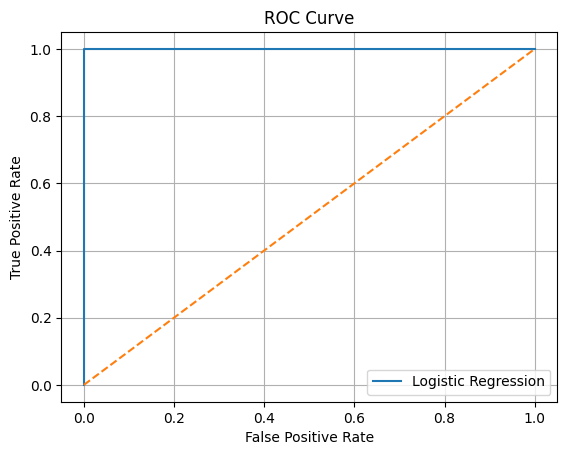

In [ ]:
plt.figure()
plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# The dashed diagonal line represents random guessing. A good model should be above this line.
# TPR (True Positive Rate) = 1.0
# The model identifies all actual positives correctly.
# FPR (False Positive Rate) = 0
# The model does not misclassify any negative as positive.

In [ ]:
# View the Coefficients ("Weights")
coefficients_ridge = pd.DataFrame({'Feature': X.columns,'Coefficient': Ridge_model.coef_[0]}).sort_values(by='Coefficient', ascending=False)

coefficients_ridge

,Feature,Coefficient
6,In_vivo_recovery,0.504623
5,Tube_formation,0.501404
3,Vascular_Marker,0.481702
4,Cell_Signalling,0.456329
1,LDL_uptake,0.214068
0,Permeability,-0.483192
2,Total_ROS,-0.486426


##### A feature importance plot shows which biomarkers contribute the most to predicting healing outcomes in the model.

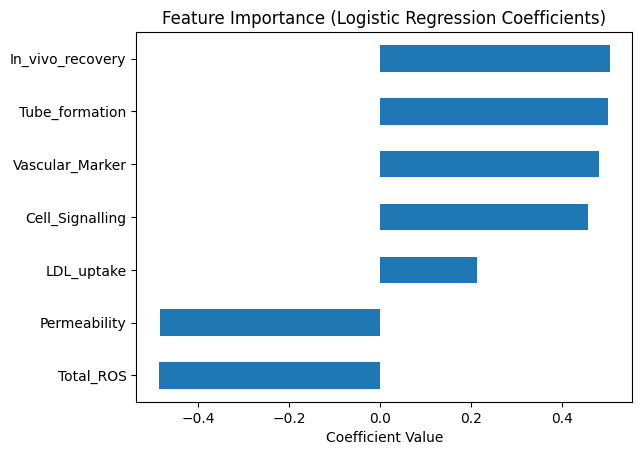

In [ ]:
feature_importance_ridge = pd.Series(Ridge_model.coef_[0], index=X.columns).sort_values()

plt.figure()
feature_importance_ridge.plot(kind="barh")
plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.xlabel("Coefficient Value")
plt.show()

In [ ]:
# The feature importance analysis aligns perfectly with the biological understanding of vascular cells.
# The ‘Good’ group is strongly driven by high vascular marker expression, strong tube-formation capacity, and active cell signalling. In contrast,
# the ‘Bad’ group is defined by elevated oxidative stress (ROS) and increased vascular permeability, both indicators of endothelial dysfunction.
# These opposing biological signatures allow the model to clearly separate the two groups, resulting in its perfect classification performance.

## 2). Lasso Classification (Logistic Regression + Lasso Regression)

In [ ]:
Lasso_model = LogisticRegression(penalty="l1", C=0.5, solver="liblinear")
Lasso_model.fit(X_train_scaled, y_train)

LogisticRegression(C=0.5, penalty='l1', solver='liblinear')

## Prediction

In [ ]:
y_pred_lasso = Lasso_model.predict(X_test_scaled)
y_prob_lasso = Lasso_model.predict_proba(X_test_scaled)[:, 1]

In [ ]:
y_prob_lasso

array([0.79937438, 0.16210793, 0.20458666, 0.75727979])

## Model Evaluation

In [ ]:
accuracy_lasso = accuracy_score(y_test, y_pred_ridge)
conf_matrix_lasso = confusion_matrix(y_test, y_pred_ridge)

class_report_lasso = classification_report(y_test, y_pred_ridge)

In [ ]:
print("Accuracy:", accuracy_lasso)

Accuracy: 1.0


In [ ]:
print("Confusion Matrix:\n", conf_matrix_lasso)

Confusion Matrix:
 [[2 0]
 [0 2]]


In [ ]:
print("Classification Report:\n", class_report_lasso)

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



In [ ]:
# Compute ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob_lasso)
auc_score_lasso = roc_auc_score(y_test, y_prob_lasso)

print("AUC Score:", auc_score_lasso)

AUC Score: 1.0


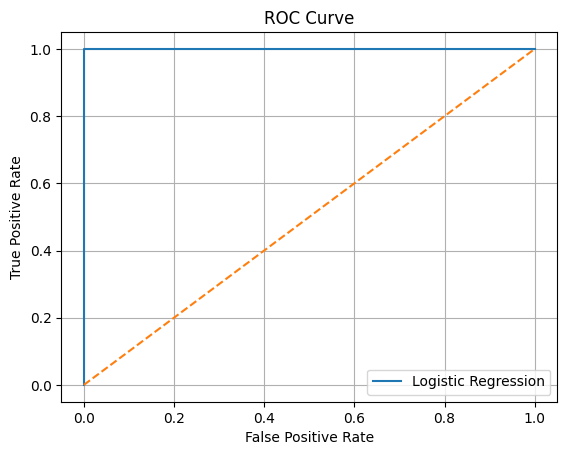

In [ ]:
plt.figure()
plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# View the Coefficients ("Weights")
coefficients_lasso = pd.DataFrame({'Feature': X.columns,'Coefficient': Lasso_model.coef_[0]}).sort_values(by='Coefficient', ascending=False)

coefficients_lasso

,Feature,Coefficient
5,Tube_formation,0.835806
6,In_vivo_recovery,0.220082
1,LDL_uptake,0.000000
4,Cell_Signalling,0.000000
2,Total_ROS,0.000000
3,Vascular_Marker,0.000000
0,Permeability,-0.329134


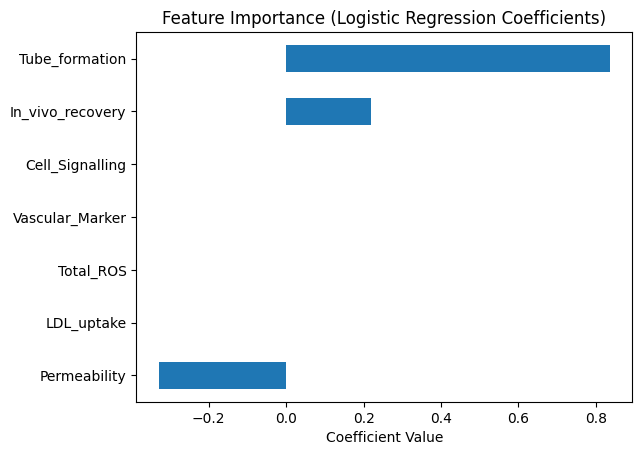

In [ ]:
# Feature Importance
feature_importance_lasso = pd.Series(Lasso_model.coef_[0], index=X.columns).sort_values()

plt.figure()
feature_importance_lasso.plot(kind="barh")
plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.xlabel("Coefficient Value")
plt.show()

In [ ]:
# When variables are extremely highly correlated (collinear), Lasso arbitrarily selects three and drops the others.
# The Lasso Regression model applied strict feature selection. Because the biological parameters are so highly correlated (redundant),
# Lasso eliminated 7 out of 7 variables, retaining only Tube formation, In vivo Recovery, Permeability.

## 3). Elastic Net Logistic Regression

In [ ]:
ElasticNet_model = LogisticRegression(
    penalty="elasticnet",
    solver="saga",
    l1_ratio=0.5,      # 0 = pure L2, 1 = pure L1, 0.5 = mix
    C=1.0,             # inverse of regularization strength
    max_iter=5000
)

ElasticNet_model.fit(X_train_scaled, y_train)

LogisticRegression(l1_ratio=0.5, max_iter=5000, penalty='elasticnet',
                   solver='saga')

### Prediction

In [ ]:
y_pred_ElasticNet = ElasticNet_model.predict(X_test_scaled)
y_prob_ElasticNet = ElasticNet_model.predict_proba(X_test_scaled)[:, 1]

In [ ]:
y_prob_ElasticNet

array([0.93989913, 0.08083318, 0.06878849, 0.88824959])

### Model Evaluation

In [ ]:
accuracy_ElasticNet = accuracy_score(y_test, y_pred_ElasticNet)
conf_matrix_ElasticNet = confusion_matrix(y_test, y_pred_ElasticNet)

class_report_ElasticNet = classification_report(y_test, y_pred_ElasticNet)

In [ ]:
print("Accuracy:", accuracy_ElasticNet)

Accuracy: 1.0


In [ ]:
print("Confusion Matrix:\n", conf_matrix_ElasticNet)

Confusion Matrix:
 [[2 0]
 [0 2]]


In [ ]:
print("Classification Report:\n", class_report_ElasticNet)

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



In [ ]:
# Compute ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob_ElasticNet)
auc_score_ElasticNet = roc_auc_score(y_test, y_prob_ElasticNet)

print("AUC Score:", auc_score_ElasticNet)

AUC Score: 1.0


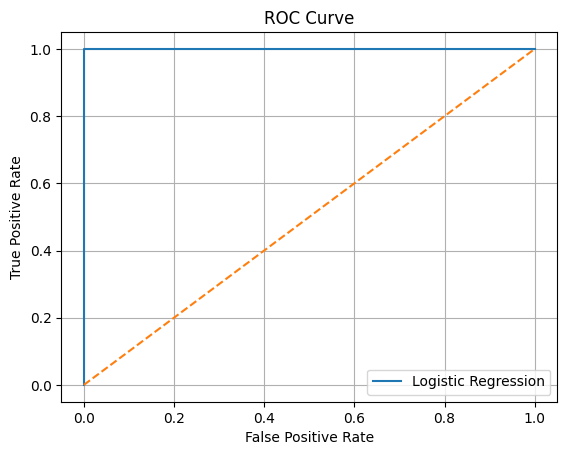

In [ ]:
plt.figure()
plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# View the Coefficients ("Weights")
coefficients_ElasticNet = pd.DataFrame({'Feature': X.columns,'Coefficient': ElasticNet_model.coef_[0]}).sort_values(by='Coefficient', ascending=False)

coefficients_ElasticNet

,Feature,Coefficient
5,Tube_formation,0.482592
6,In_vivo_recovery,0.459693
3,Vascular_Marker,0.427164
4,Cell_Signalling,0.382644
1,LDL_uptake,0.000000
2,Total_ROS,-0.405621
0,Permeability,-0.436583


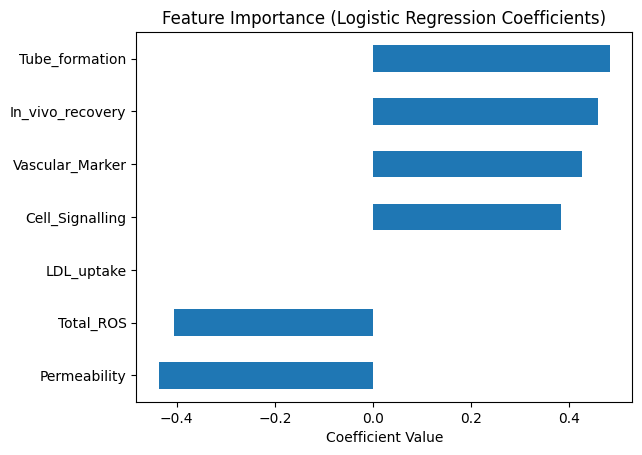

In [ ]:
# Feature Importance
feature_importance_ElasticNet = pd.Series(ElasticNet_model.coef_[0], index=X.columns).sort_values()

plt.figure()
feature_importance_ElasticNet.plot(kind="barh")
plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.xlabel("Coefficient Value")
plt.show()

<Figure size 1000x600 with 0 Axes>

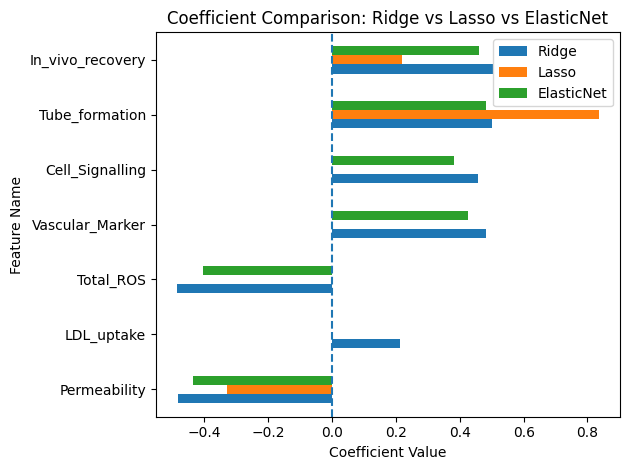

In [ ]:
# Compare the coefficients of Each Model
coefficients_ridge = pd.Series(Ridge_model.coef_[0], index=X.columns, name="Ridge")
coefficients_lasso = pd.Series(Lasso_model.coef_[0], index=X.columns, name="Lasso")
coefficients_ElasticNet = pd.Series(ElasticNet_model.coef_[0], index=X.columns, name="ElasticNet")

# Combine into one DataFrame
coef_df = pd.concat([coefficients_ridge, coefficients_lasso, coefficients_ElasticNet], axis=1)

plt.figure(figsize=(10, 6))
coef_df.plot(kind="barh")

plt.axvline(0, linestyle="--")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature Name")
plt.title("Coefficient Comparison: Ridge vs Lasso vs ElasticNet")

plt.tight_layout()
plt.show()

In [ ]:
# Ridge shows that many features contribute to the classification.
# Lasso identifies Vascular Marker as the single strongest independent predictor, eliminating all other correlated features.
# ElasticNet provides a balanced view, keeping multiple biologically meaningful features while still emphasizing Vascular Marker as dominant.

### Fitting SVM Model

In [ ]:
# Training SVM Model
svm_model = SVC(kernel="rbf", C=1.0, gamma="scale", probability=True)
svm_model.fit(X_train_scaled, y_train)

SVC(probability=True)

In [ ]:
# Prediction
y_pred_svm = svm_model.predict(X_test_scaled)
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:, 1]   # Probabilities for ROC

In [ ]:
y_prob_svm

array([0.82053852, 0.11824323, 0.1063085 , 0.7996409 ])

In [ ]:
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

SVM Accuracy: 1.0


In [ ]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))

Confusion Matrix:
 [[2 0]
 [0 2]]


In [ ]:
print("Classification Report:\n", classification_report(y_test, y_pred_svm))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



In [ ]:
# Compute ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob_svm)
auc_score_svm = roc_auc_score(y_test, y_prob_svm)

print("AUC Score:", auc_score_svm)

AUC Score: 1.0


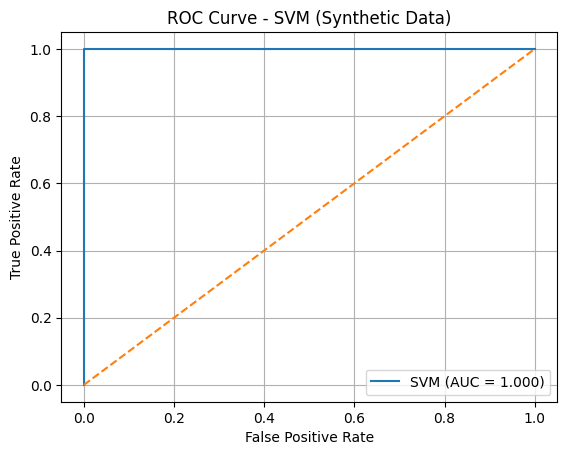

In [ ]:
# Plot ROC
plt.figure()
plt.plot(fpr, tpr, label=f"SVM (AUC = {auc_score_svm:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")   # random classifier line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM (Synthetic Data)")
plt.legend()
plt.grid(True)
plt.show()

## Fitting Principal Component Analysis (PCA)
##### PCA is a method that simplifies complex data by converting many correlated variables into a few new, independent variables while keeping most of the information.

###### PCA Calculation

In [ ]:
X

,Permeability,LDL_uptake,Total_ROS,Vascular_Marker,Cell_Signalling,Tube_formation,In_vivo_recovery
0,71,0.30,1.8,68,43,39,35
1,68,0.34,1.9,75,47,35,34
2,20,1.20,1.0,100,80,100,70
3,79,0.19,1.8,70,43,41,28
4,17,1.30,0.9,96,88,92,72
5,69,2.00,2.2,74,55,44,19
6,22,1.40,1.1,96,85,99,79
7,23,1.10,0.9,98,78,98,78
8,70,0.35,2.1,69,59,46,22
9,21,1.80,0.8,92,95,96,82


In [ ]:
y

,Group
0,0
1,0
2,1
3,0
4,1
5,0
6,1
7,1
8,0
9,1


In [ ]:
# Scale first
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X_scaled

array([[ 0.97648269, -1.04399688,  0.66186007, -1.39672248, -1.28796283,
        -1.01016467, -0.68935924],
       [ 0.85997055, -0.98044924,  0.85096294, -0.81177033, -1.08247588,
        -1.15053494, -0.72957186],
       [-1.00422367,  0.38582493, -0.85096294,  1.27734449,  0.61279143,
         1.13048205,  0.71808254],
       [ 1.28718172, -1.21875288,  0.66186007, -1.2295933 , -1.28796283,
        -0.93997953, -0.97084759],
       [-1.12073581,  0.54469402, -1.04006582,  0.94308612,  1.02376532,
         0.84974149,  0.79850778],
       [ 0.89880793,  1.65677766,  1.41827157, -0.89533492, -0.67150199,
        -0.83470182, -1.33276119],
       [-0.92654891,  0.70356311, -0.66186007,  0.94308612,  0.86965011,
         1.09538948,  1.07999614],
       [-0.88771153,  0.22695584, -1.04006582,  1.11021531,  0.51004796,
         1.06029691,  1.03978352],
       [ 0.93764531, -0.96456233,  1.2291687 , -1.31315789, -0.46601504,
        -0.76451668, -1.21212332],
       [-0.96538629,  1.3390

In [ ]:
# We calculate all components first to see the full variance
pca = PCA()
pca.fit(X_scaled)

PCA()

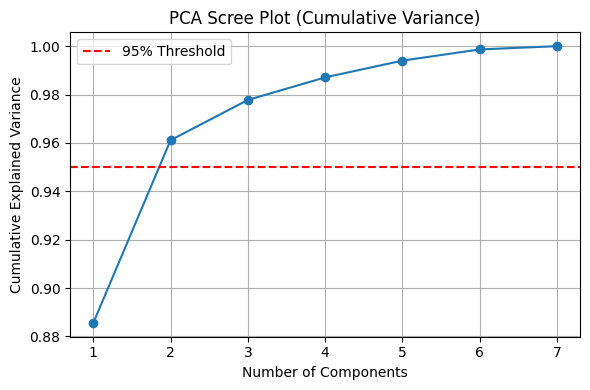

In [ ]:
# Calculate variance explained
explained_var = pca.explained_variance_ratio_
cum_explained = np.cumsum(explained_var)

plt.figure(figsize=(6,4))
plt.plot(range(1, len(explained_var)+1), cum_explained, marker="o")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Scree Plot (Cumulative Variance)")
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Threshold')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Component 1 captures ~88% of the information
# Component 2 pushes it to ~96%
# After component 2, the curve flattens
# Only the first 2 PCA components are enough. They cover more than 95% of all information in your dataset.

In [ ]:
explained_variance = pd.DataFrame({
    "Principal_Component": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
    "Explained_Variance (%)": pca.explained_variance_ratio_ * 100
})

In [ ]:
print(explained_variance)

  Principal_Component  Explained_Variance (%)
0                 PC1               88.559491
1                 PC2                7.553270
2                 PC3                1.662514
3                 PC4                0.933163
4                 PC5                0.692808
5                 PC6                0.462831
6                 PC7                0.135923


In [ ]:
# Reduce 7D → 2D with PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [ ]:
print("Number of PCA components used:", pca.n_components_)

Number of PCA components used: 2


In [ ]:
X_pca

array([[ 2.65853844, -0.37989095],
       [ 2.4335732 , -0.32838768],
       [-2.29402013, -0.33253057],
       [ 2.85181795, -0.47344969],
       [-2.41369756, -0.16000446],
       [ 1.85142902,  2.40567943],
       [-2.38388265, -0.00539807],
       [-2.26452058, -0.58523144],
       [ 2.58869659,  0.03650847],
       [-2.88667686,  0.49022232],
       [ 2.38301374, -0.31321038],
       [ 2.51361563, -0.47084308],
       [-1.96364891, -0.15581511],
       [-3.07423788,  0.2723512 ]])

In [ ]:
features = X.columns

In [ ]:
features

Index(['Permeability', 'LDL_uptake', 'Total_ROS', 'Vascular_Marker',
       'Cell_Signalling', 'Tube_formation', 'In_vivo_recovery'],
      dtype='object')

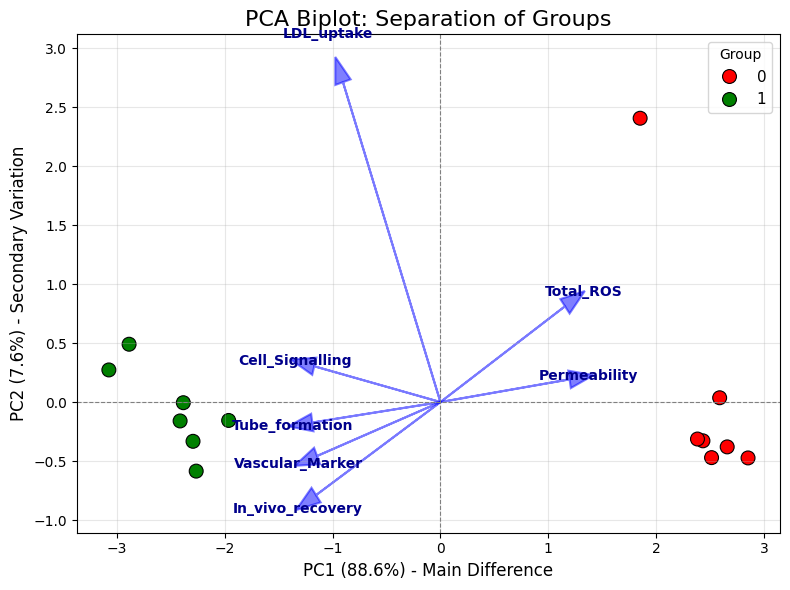

In [ ]:
# Biplot(Clusters + Arrows)
plt.figure(figsize=(8, 6))

# Scatter plot of samples (PC1 vs PC2)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette={1: 'green', 0: 'red'}, s=100, edgecolor='black')

# Draw Feature Vectors (Arrows)
# We scale arrows to fit the plot dimensions
scale_factor = 3.0

for i, feature in enumerate(features):
    x_vec = pca.components_[0, i] * scale_factor
    y_vec = pca.components_[1, i] * scale_factor

    # Draw arrow
    plt.arrow(0, 0, x_vec, y_vec, color='blue', alpha=0.5, head_width=0.15, linewidth=1.5)

    # Add text label
    plt.text(x_vec * 1.15, y_vec * 1.15, feature, color='darkblue', ha='center', va='center', fontsize=10, weight='bold')

# Labels and Formatting
plt.title('PCA Biplot: Separation of Groups', fontsize=16)
plt.xlabel(f'PC1 ({explained_var[0]*100:.1f}%) - Main Difference', fontsize=12)
plt.ylabel(f'PC2 ({explained_var[1]*100:.1f}%) - Secondary Variation', fontsize=12)
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.axvline(0, color='grey', linestyle='--', linewidth=0.8)
plt.grid(True, alpha=0.3)
plt.legend(title='Group', fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
# Arrow direction = which group the feature is associated with
# Arrows to the right: Total ROS, Permeability
#   → higher in red group
# Arrows to the left: Vascular marker, Tube formation, In vivo recovery, cell Signalling
#    → higher in green group

# LDL uptake arrow is longest → contributes most to PC2
# Total ROS + Permeability → drive PC1 strongly
# Tube formation, vascular marker, recovery → moderate contributors

# Group 0 represents a state of high Permeability and Oxidative Stress (ROS).
# Group 1 represents a state of active biological function/recovery, characterized by high Signalling, Vascular Markers, and Recovery.

#  Train classifier on PCA components

In [ ]:
X

,Permeability,LDL_uptake,Total_ROS,Vascular_Marker,Cell_Signalling,Tube_formation,In_vivo_recovery
0,71,0.30,1.8,68,43,39,35
1,68,0.34,1.9,75,47,35,34
2,20,1.20,1.0,100,80,100,70
3,79,0.19,1.8,70,43,41,28
4,17,1.30,0.9,96,88,92,72
5,69,2.00,2.2,74,55,44,19
6,22,1.40,1.1,96,85,99,79
7,23,1.10,0.9,98,78,98,78
8,70,0.35,2.1,69,59,46,22
9,21,1.80,0.8,92,95,96,82


In [ ]:
y

,Group
0,0
1,0
2,1
3,0
4,1
5,0
6,1
7,1
8,0
9,1


In [ ]:
# Split data into training (72%) and testing (28%) sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.28, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((10, 7), (4, 7), (10,), (4,))

In [ ]:
# Scale the Data (Standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [ ]:
X_train_scaled

array([[ 0.92696496,  1.64324694,  1.36816673, -0.90227304, -0.71577984,
        -0.89377438, -1.25120577],
       [ 0.9652693 , -1.03596003,  1.1857445 , -1.29456567, -0.49033737,
        -0.82283991, -1.12933508],
       [-0.94994756,  0.3442375 , -0.82090004,  1.13764862,  0.69323559,
         1.09239091,  0.82059599],
       [ 0.88866063, -1.05219764,  0.82090004, -0.82381452, -1.16666478,
        -1.21297952, -0.64185231],
       [-1.21807793,  1.1561184 , -1.36816673,  1.13764862,  1.369563  ,
         0.9859892 ,  0.86121956],
       [-1.06486058,  0.50661368, -1.00332227,  0.82381452,  1.14412053,
         0.80865301,  0.90184312],
       [-0.83503455,  0.18186132, -1.00332227,  0.98073157,  0.58051436,
         1.02145644,  1.1455845 ],
       [ 0.85035629, -1.11714812,  0.82090004, -0.66689747, -0.99758292,
        -1.03564333, -1.00746439],
       [ 1.31000834, -1.29576191,  0.63847781, -1.21610715, -1.39210724,
        -1.00017609, -0.88559369],
       [-0.87333889,  0.6689

In [ ]:
y_test

,Group
9,1
11,0
0,0
12,1


In [ ]:
pca = PCA(n_components=2)
X_train_scaled_pca = pca.fit_transform(X_train_scaled)
X_test_scaled_pca  = pca.transform(X_test_scaled)

## 1). Fitting Logistic Model

##### a). PCA + Logistic Regression

In [ ]:
clf_pca = LogisticRegression()
clf_pca.fit(X_train_scaled_pca, y_train)

LogisticRegression()

##### Prediction

In [ ]:
y_pred = clf_pca.predict(X_test_scaled_pca)
y_prob = clf_pca.predict_proba(X_test_scaled_pca)[:, 1]

In [ ]:
y_prob

array([0.96730496, 0.04817339, 0.04021877, 0.91603864])

##### Model Evaluation

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

class_report = classification_report(y_test, y_pred)

In [ ]:
print("Accuracy:", accuracy)

Accuracy: 1.0


In [ ]:
print("Confusion Matrix:\n", conf_matrix)

Confusion Matrix:
 [[2 0]
 [0 2]]


In [ ]:
print("Classification Report:\n", class_report)

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



In [ ]:
# Compute ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc_score)

AUC Score: 1.0


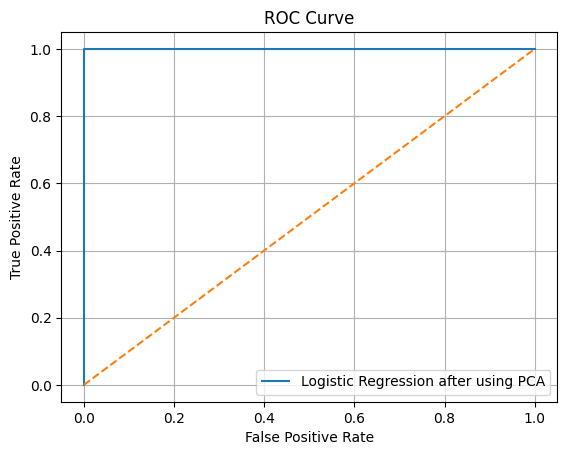

In [ ]:
plt.figure()
plt.plot(fpr, tpr, label="Logistic Regression after using PCA")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
X_pca_features = ['PC1', 'PC2']


In [ ]:
# View the Coefficients ("Weights")
coefficients = pd.DataFrame({'Feature': X_pca_features,'Coefficient': clf_pca.coef_[0]}).sort_values(by='Coefficient', ascending=False)

coefficients

,Feature,Coefficient
1,PC2,-0.108426
0,PC1,-1.204415


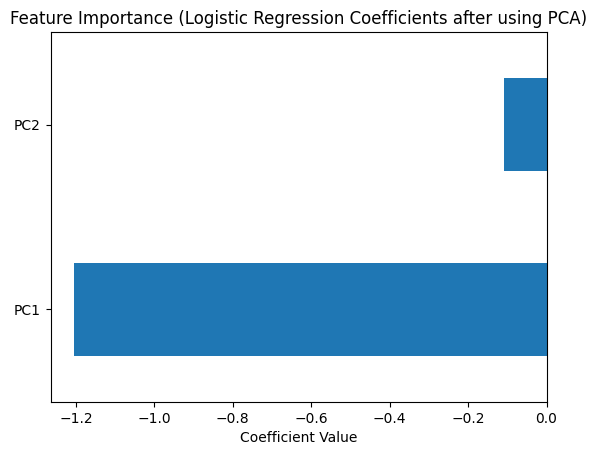

In [ ]:
# Feature Importance
feature_importance = pd.Series(clf_pca.coef_[0], index=X_pca_features).sort_values()

plt.figure()
feature_importance.plot(kind="barh")
plt.title("Feature Importance (Logistic Regression Coefficients after using PCA)")
plt.xlabel("Coefficient Value")
plt.show()

In [ ]:
# After applying PCA, Logistic Regression shows that PC1 is the most influential component in classification,
# while PC2 contributes only marginally. This indicates that the majority of discriminatory
# information between the groups is captured by the first principal component.

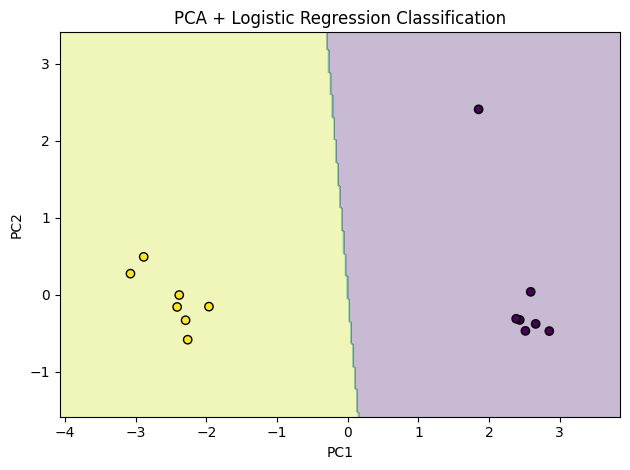

In [ ]:
# Create mesh grid
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

# Predict over grid
Z = clf_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
plt.figure()
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, edgecolors="k")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA + Logistic Regression Classification")
plt.tight_layout()
plt.show()

In [ ]:
# After reducing the data using PCA, we trained a Logistic Regression classifier on the first two principal components.
# The plot shows a clear linear decision boundary that cleanly separates the two groups with minimal overlap.
# This explains the high classification accuracy achieved by the model.

## 2). Fitting SVM Model

In [ ]:
# Training SVM Model
clf_svm_pca = SVC(kernel="linear", C=1.0, probability=True)
clf_svm_pca.fit(X_train_scaled_pca, y_train)

SVC(kernel='linear', probability=True)

In [ ]:
# Prediction
y_pred = clf_svm_pca.predict(X_test_scaled_pca)
y_prob = clf_svm_pca.predict_proba(X_test_scaled_pca)[:, 1]   # Probabilities for ROC

In [ ]:
y_prob

array([0.88226666, 0.13745844, 0.12415634, 0.80814162])

In [ ]:
print("SVM Accuracy:", accuracy_score(y_test, y_pred))

SVM Accuracy: 1.0


In [ ]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Confusion Matrix:
 [[2 0]
 [0 2]]


In [ ]:
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



In [ ]:
# Compute ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc_score)

AUC Score: 1.0


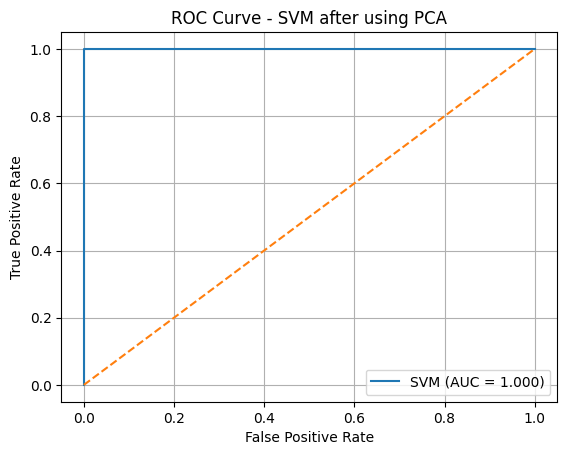

In [ ]:
# Plot ROC
plt.figure()
plt.plot(fpr, tpr, label=f"SVM (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")   # random classifier line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM after using PCA")
plt.legend()
plt.grid(True)
plt.show()

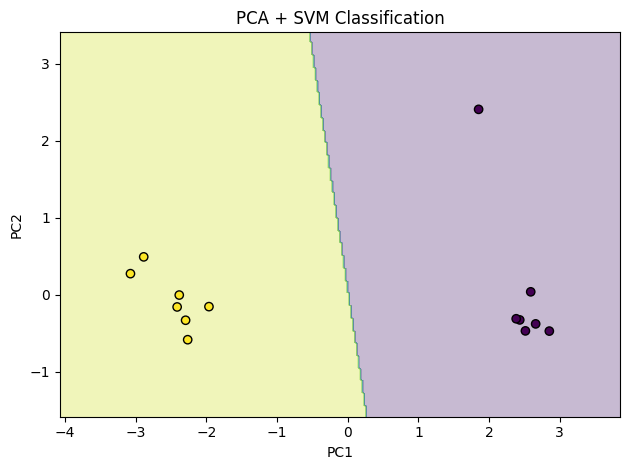

In [ ]:
# Predict over grid using SVM
Z_svm = clf_svm_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z_svm = Z_svm.reshape(xx.shape)

# Plot
plt.figure()
plt.contourf(xx, yy, Z_svm, alpha=0.3)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, edgecolors="k")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA + SVM Classification")
plt.tight_layout()
plt.show()

In [ ]:
# This plot shows how a Support Vector Machine (SVM) separates the two groups after reducing the data to two principal components (PC1 and PC2).
# After PCA transformation, we applied a linear SVM classifier using the first two principal components.
# The resulting decision boundary shows a clear and wide-margin separation between the two groups, primarily along the PC1 axis.

## Construction of a Composite Vascular Health Score

## 1). Equal Weighting (EW) Method
##### Equal weighting means that no indicator or domain is assumed to be more important than another.
##### In this study, equal weighting is applied at the domain level, so that each biological domain contributes equally to the final Health Score. Within each domain, indicators share the domain’s weight equally.

In [ ]:
# Group - 1 data i.e Good = 1
data1 = {
    'Permeability' : [20, 23, 22, 27, 21, 17, 13],
    'LDL_uptake': [0.3, 2.0, 0.3, 0.22, 0.34, 0.19, 0.35],
    'Total_ROS': [1, 0.9, 1.1, 1.2, 0.8, 0.9, 0.7],
    'Vascular_Marker' : [100, 98, 96, 90, 92, 96, 100],
    'Cell_Signalling': [80, 78, 85, 89, 95, 88, 92],
    'Tube_formation': [100, 98, 99, 90, 96, 92, 97],
    'In_vivo_recovery': [70, 78, 79, 83, 82, 72, 71],
    'Group': [1]*7                                        # 1 is Good
}

In [ ]:
# Group - 2 data i.e. Bad = 0
data2 = {
    'Permeability' : [67, 69, 71, 75, 68, 79, 70],
    'LDL_uptake': [1.2, 1.1, 1.4, 1.2, 1.8, 1.3, 1.7],
    'Total_ROS': [1.9, 2.2, 1.8, 2, 1.9, 1.8, 2.1],
    'Vascular_Marker' : [77, 74, 68, 81, 75, 70, 69],
    'Cell_Signalling': [50, 55, 43, 49, 47, 43, 59],
    'Tube_formation': [40, 44, 39, 32, 35, 41, 46],
    'In_vivo_recovery': [25, 19, 35, 32, 34, 28, 22],
    'Group': [0]*7                                      # 0 is Bad
}

In [ ]:
df1 = pd.DataFrame(data1)

In [ ]:
df2 = pd.DataFrame(data2)

In [ ]:
df = pd.concat([df1, df2], ignore_index=True)

In [ ]:
df

,Permeability,LDL_uptake,Total_ROS,Vascular_Marker,Cell_Signalling,Tube_formation,In_vivo_recovery,Group
0,20,0.30,1.0,100,80,100,70,1
1,23,2.00,0.9,98,78,98,78,1
2,22,0.30,1.1,96,85,99,79,1
3,27,0.22,1.2,90,89,90,83,1
4,21,0.34,0.8,92,95,96,82,1
5,17,0.19,0.9,96,88,92,72,1
6,13,0.35,0.7,100,92,97,71,1
7,67,1.20,1.9,77,50,40,25,0
8,69,1.10,2.2,74,55,44,19,0
9,71,1.40,1.8,68,43,39,35,0


In [ ]:
# Shuffle original dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
df

,Permeability,LDL_uptake,Total_ROS,Vascular_Marker,Cell_Signalling,Tube_formation,In_vivo_recovery,Group
0,71,1.40,1.8,68,43,39,35,0
1,68,1.80,1.9,75,47,35,34,0
2,20,0.30,1.0,100,80,100,70,1
3,79,1.30,1.8,70,43,41,28,0
4,17,0.19,0.9,96,88,92,72,1
5,69,1.10,2.2,74,55,44,19,0
6,22,0.30,1.1,96,85,99,79,1
7,23,2.00,0.9,98,78,98,78,1
8,70,1.70,2.1,69,59,46,22,0
9,21,0.34,0.8,92,95,96,82,1


In [ ]:
# Indicators where higher = better
positive_indicators = ["LDL_uptake", "Vascular_Marker", "Cell_Signalling", "Tube_formation","In_vivo_recovery"]

# Indicators where higher = worse (need inversion)
negative_indicators = ["Permeability", "Total_ROS"]

# All indicators (7 total)
all_indicators = positive_indicators + negative_indicators

### Min–Max normalisation
For every indicator: higher = better health

In [ ]:
df_norm = df.copy()

# Normalise positive indicators
for col in positive_indicators:
    df_norm[col] = (df[col] - df[col].min()) / (df[col].max() - df[col].min())

# Normalise negative indicators (invert)
for col in negative_indicators:
    df_norm[col] = (df[col].max() - df[col]) / (df[col].max() - df[col].min())

In [ ]:
df_norm

,Permeability,LDL_uptake,Total_ROS,Vascular_Marker,Cell_Signalling,Tube_formation,In_vivo_recovery,Group
0,0.121212,0.668508,0.266667,0.00000,0.000000,0.102941,0.250000,0
1,0.166667,0.889503,0.200000,0.21875,0.076923,0.044118,0.234375,0
2,0.893939,0.060773,0.800000,1.00000,0.711538,1.000000,0.796875,1
3,0.000000,0.613260,0.266667,0.06250,0.000000,0.132353,0.140625,0
4,0.939394,0.000000,0.866667,0.87500,0.865385,0.882353,0.828125,1
5,0.151515,0.502762,0.000000,0.18750,0.230769,0.176471,0.000000,0
6,0.863636,0.060773,0.733333,0.87500,0.807692,0.985294,0.937500,1
7,0.848485,1.000000,0.866667,0.93750,0.673077,0.970588,0.921875,1
8,0.136364,0.834254,0.066667,0.03125,0.307692,0.205882,0.046875,0
9,0.878788,0.082873,0.933333,0.75000,1.000000,0.941176,0.984375,1


In [ ]:
# Domains
barrier_stress = ["Permeability", "Total_ROS"]
vascular_function = ["LDL_uptake", "Cell_Signalling"]
recovery = ["Vascular_Marker", "Tube_formation", "In_vivo_recovery"]

### a) Equal weighting by giving 1/7 weight to each indicator

*   We assume all indicators are equally important.
*   Since there are 7 indicators, each one gets a weight of 1/7.
*   No indicator or domain is prioritised over another.

##### Limitation -> Domains with more indicators automatically influence the score more.

In [ ]:
# Equal weighting: 1/7 per indicator
df_norm["Health_Score_EW_1by7"] = df_norm[all_indicators].mean(axis=1)

In [ ]:
df_norm

,Permeability,LDL_uptake,Total_ROS,Vascular_Marker,Cell_Signalling,Tube_formation,In_vivo_recovery,Group,Health_Score_EW_1by7
0,0.121212,0.668508,0.266667,0.00000,0.000000,0.102941,0.250000,0,0.201333
1,0.166667,0.889503,0.200000,0.21875,0.076923,0.044118,0.234375,0,0.261476
2,0.893939,0.060773,0.800000,1.00000,0.711538,1.000000,0.796875,1,0.751875
3,0.000000,0.613260,0.266667,0.06250,0.000000,0.132353,0.140625,0,0.173629
4,0.939394,0.000000,0.866667,0.87500,0.865385,0.882353,0.828125,1,0.750989
5,0.151515,0.502762,0.000000,0.18750,0.230769,0.176471,0.000000,0,0.178431
6,0.863636,0.060773,0.733333,0.87500,0.807692,0.985294,0.937500,1,0.751890
7,0.848485,1.000000,0.866667,0.93750,0.673077,0.970588,0.921875,1,0.888313
8,0.136364,0.834254,0.066667,0.03125,0.307692,0.205882,0.046875,0,0.232712
9,0.878788,0.082873,0.933333,0.75000,1.000000,0.941176,0.984375,1,0.795792


### b) Equal weight to each domain


*   Each biological domain is given the same importance in the health score.
*   Indicators within a domain share the domain’s weight equally.
*   This prevents any one domain from dominating the score just because it has more indicators.



In [ ]:
df_norm["Health_Score_EW"] = (
    (1/3) * df_norm[barrier_stress].mean(axis=1) +
    (1/3) * df_norm[vascular_function].mean(axis=1) +
    (1/3) * df_norm[recovery].mean(axis=1)
)

In [ ]:
df_norm

,Permeability,LDL_uptake,Total_ROS,Vascular_Marker,Cell_Signalling,Tube_formation,In_vivo_recovery,Group,Health_Score_EW_1by7,Health_Score_EW
0,0.121212,0.668508,0.266667,0.00000,0.000000,0.102941,0.250000,0,0.201333,0.215280
1,0.166667,0.889503,0.200000,0.21875,0.076923,0.044118,0.234375,0,0.261476,0.277431
2,0.893939,0.060773,0.800000,1.00000,0.711538,1.000000,0.796875,1,0.751875,0.721806
3,0.000000,0.613260,0.266667,0.06250,0.000000,0.132353,0.140625,0,0.173629,0.183930
4,0.939394,0.000000,0.866667,0.87500,0.865385,0.882353,0.828125,1,0.750989,0.732516
5,0.151515,0.502762,0.000000,0.18750,0.230769,0.176471,0.000000,0,0.178431,0.187949
6,0.863636,0.060773,0.733333,0.87500,0.807692,0.985294,0.937500,1,0.751890,0.721772
7,0.848485,1.000000,0.866667,0.93750,0.673077,0.970588,0.921875,1,0.888313,0.879145
8,0.136364,0.834254,0.066667,0.03125,0.307692,0.205882,0.046875,0,0.232712,0.255719
9,0.878788,0.082873,0.933333,0.75000,1.000000,0.941176,0.984375,1,0.795792,0.779783


### c) Equal weight within domains, but domains have different weight

*   Indicators are equal inside each domain.
*   Some domains are given more importance


i) Higher weight to postive indicator

In [ ]:
# Unequal domain weights (must sum to 1)
w_barrier   = 0.25
w_vascular  = 0.25
w_recovery  = 0.50

In [ ]:
# Health Score (unequal domain weighting)
df_norm["Health_Score_unequal"] = (
    w_barrier  * df_norm[barrier_stress].mean(axis=1) +
    w_vascular * df_norm[vascular_function].mean(axis=1) +
    w_recovery * df_norm[recovery].mean(axis=1)
)

In [ ]:
df_norm

,Permeability,LDL_uptake,Total_ROS,Vascular_Marker,Cell_Signalling,Tube_formation,In_vivo_recovery,Group,Health_Score_EW_1by7,Health_Score_EW,Health_Score_unequal
0,0.121212,0.668508,0.266667,0.00000,0.000000,0.102941,0.250000,0,0.201333,0.215280,0.190872
1,0.166667,0.889503,0.200000,0.21875,0.076923,0.044118,0.234375,0,0.261476,0.277431,0.249510
2,0.893939,0.060773,0.800000,1.00000,0.711538,1.000000,0.796875,1,0.751875,0.721806,0.774427
3,0.000000,0.613260,0.266667,0.06250,0.000000,0.132353,0.140625,0,0.173629,0.183930,0.165904
4,0.939394,0.000000,0.866667,0.87500,0.865385,0.882353,0.828125,1,0.750989,0.732516,0.764844
5,0.151515,0.502762,0.000000,0.18750,0.230769,0.176471,0.000000,0,0.178431,0.187949,0.171293
6,0.863636,0.060773,0.733333,0.87500,0.807692,0.985294,0.937500,1,0.751890,0.721772,0.774478
7,0.848485,1.000000,0.866667,0.93750,0.673077,0.970588,0.921875,1,0.888313,0.879145,0.895189
8,0.136364,0.834254,0.066667,0.03125,0.307692,0.205882,0.046875,0,0.232712,0.255719,0.215457
9,0.878788,0.082873,0.933333,0.75000,1.000000,0.941176,0.984375,1,0.795792,0.779783,0.807800


ii) Higher weight to negative indicaotrs

In [ ]:
# Unequal domain weights (must sum to 1)
w_barrier   = 0.50
w_vascular  = 0.20
w_recovery  = 0.30

In [ ]:
# Health Score (unequal domain weighting)
df_norm["Health_Score_unequal2"] = (
    w_barrier  * df_norm[barrier_stress].mean(axis=1) +
    w_vascular * df_norm[vascular_function].mean(axis=1) +
    w_recovery * df_norm[recovery].mean(axis=1)
)

In [ ]:
df_norm

,Permeability,LDL_uptake,Total_ROS,Vascular_Marker,Cell_Signalling,Tube_formation,In_vivo_recovery,Group,Health_Score_EW_1by7,Health_Score_EW,Health_Score_unequal,Health_Score_unequal2
0,0.121212,0.668508,0.266667,0.00000,0.000000,0.102941,0.250000,0,0.201333,0.215280,0.190872,0.199115
1,0.166667,0.889503,0.200000,0.21875,0.076923,0.044118,0.234375,0,0.261476,0.277431,0.249510,0.238034
2,0.893939,0.060773,0.800000,1.00000,0.711538,1.000000,0.796875,1,0.751875,0.721806,0.774427,0.780404
3,0.000000,0.613260,0.266667,0.06250,0.000000,0.132353,0.140625,0,0.173629,0.183930,0.165904,0.161540
4,0.939394,0.000000,0.866667,0.87500,0.865385,0.882353,0.828125,1,0.750989,0.732516,0.764844,0.796601
5,0.151515,0.502762,0.000000,0.18750,0.230769,0.176471,0.000000,0,0.178431,0.187949,0.171293,0.147629
6,0.863636,0.060773,0.733333,0.87500,0.807692,0.985294,0.937500,1,0.751890,0.721772,0.774478,0.765868
7,0.848485,1.000000,0.866667,0.93750,0.673077,0.970588,0.921875,1,0.888313,0.879145,0.895189,0.879092
8,0.136364,0.834254,0.066667,0.03125,0.307692,0.205882,0.046875,0,0.232712,0.255719,0.215457,0.193353
9,0.878788,0.082873,0.933333,0.75000,1.000000,0.941176,0.984375,1,0.795792,0.779783,0.807800,0.828873


### Create Two Domain, then calculate weight

In [ ]:
# Two domains
domain_stress = ["Permeability", "LDL_uptake", "Total_ROS"]
domain_function_recovery = [
    "Vascular_Marker",
    "Cell_Signalling",
    "Tube_formation",
    "In_vivo_recovery"
]

In [ ]:
# Domain weights (must sum to 1)
w_stress = 0.50
w_function_recovery = 0.50

In [ ]:
# Health score (two-domain, unequal weighting)
df_norm["Health_Score_2domain_EW"] = (
    w_stress * df_norm[domain_stress].mean(axis=1) +
    w_function_recovery * df_norm[domain_function_recovery].mean(axis=1)
)

In [ ]:
df_norm

,Permeability,LDL_uptake,Total_ROS,Vascular_Marker,Cell_Signalling,Tube_formation,In_vivo_recovery,Group,Health_Score_EW_1by7,Health_Score_EW,Health_Score_unequal,Health_Score_unequal2,Health_Score_2domain_EW
0,0.121212,0.668508,0.266667,0.00000,0.000000,0.102941,0.250000,0,0.201333,0.215280,0.190872,0.199115,0.220182
1,0.166667,0.889503,0.200000,0.21875,0.076923,0.044118,0.234375,0,0.261476,0.277431,0.249510,0.238034,0.281132
2,0.893939,0.060773,0.800000,1.00000,0.711538,1.000000,0.796875,1,0.751875,0.721806,0.774427,0.780404,0.731004
3,0.000000,0.613260,0.266667,0.06250,0.000000,0.132353,0.140625,0,0.173629,0.183930,0.165904,0.161540,0.188589
4,0.939394,0.000000,0.866667,0.87500,0.865385,0.882353,0.828125,1,0.750989,0.732516,0.764844,0.796601,0.732368
5,0.151515,0.502762,0.000000,0.18750,0.230769,0.176471,0.000000,0,0.178431,0.187949,0.171293,0.147629,0.183389
6,0.863636,0.060773,0.733333,0.87500,0.807692,0.985294,0.937500,1,0.751890,0.721772,0.774478,0.765868,0.726976
7,0.848485,1.000000,0.866667,0.93750,0.673077,0.970588,0.921875,1,0.888313,0.879145,0.895189,0.879092,0.890405
8,0.136364,0.834254,0.066667,0.03125,0.307692,0.205882,0.046875,0,0.232712,0.255719,0.215457,0.193353,0.246843
9,0.878788,0.082873,0.933333,0.75000,1.000000,0.941176,0.984375,1,0.795792,0.779783,0.807800,0.828873,0.775276


In [ ]:
# The similarity of health scores across multiple weighting strategies indicates that the health score is robust and not sensitive to the choice of weighting scheme.
# Biomarkers show a clear and consistent biological pattern:
# -> Healthy samples have high values for recovery, angiogenesis, and vascular markers
# -> Unhealthy samples have higher stress and permeability-related markers
# Because the biology is clear and aligned, all scoring methods capture the same signal.

In [ ]:
df["Health_Score_EW"] = (df_norm["Health_Score_EW"].values) * 100

In [ ]:
df

,Permeability,LDL_uptake,Total_ROS,Vascular_Marker,Cell_Signalling,Tube_formation,In_vivo_recovery,Group,Health_Score_EW
0,71,1.40,1.8,68,43,39,35,0,21.528020
1,68,1.80,1.9,75,47,35,34,0,27.743127
2,20,0.30,1.0,100,80,100,70,1,72.180578
3,79,1.30,1.8,70,43,41,28,0,18.392972
4,17,0.19,0.9,96,88,92,72,1,73.251620
5,69,1.10,2.2,74,55,44,19,0,18.794898
6,22,0.30,1.1,96,85,99,79,1,72.177193
7,23,2.00,0.9,98,78,98,78,1,87.914510
8,70,1.70,2.1,69,59,46,22,0,25.571916
9,21,0.34,0.8,92,95,96,82,1,77.978252


2). PCA Based Method

### a). With changing the direction of negative indicator

In [ ]:
df = df.drop(columns=["Health_Score_EW"])

In [ ]:
df

,Permeability,LDL_uptake,Total_ROS,Vascular_Marker,Cell_Signalling,Tube_formation,In_vivo_recovery,Group
0,71,0.30,1.8,68,43,39,35,0
1,68,0.34,1.9,75,47,35,34,0
2,20,1.20,1.0,100,80,100,70,1
3,79,0.19,1.8,70,43,41,28,0
4,17,1.30,0.9,96,88,92,72,1
5,69,2.00,2.2,74,55,44,19,0
6,22,1.40,1.1,96,85,99,79,1
7,23,1.10,0.9,98,78,98,78,1
8,70,0.35,2.1,69,59,46,22,0
9,21,1.80,0.8,92,95,96,82,1


In [ ]:
df_pca = df.copy()

In [ ]:
for col in negative_indicators:
    df_pca[col] = df_pca[col].max() - df_pca[col]

In [ ]:
# We align all indicators so that higher values consistently represent better health, ensuring a clear and interpretable PCA-based health score.

In [ ]:
indicators = df_pca.drop(columns=["Group"]).columns

In [ ]:
indicators

Index(['Permeability', 'LDL_uptake', 'Total_ROS', 'Vascular_Marker',
       'Cell_Signalling', 'Tube_formation', 'In_vivo_recovery'],
      dtype='object')

In [ ]:
X = df_pca[indicators]

In [ ]:
X

,Permeability,LDL_uptake,Total_ROS,Vascular_Marker,Cell_Signalling,Tube_formation,In_vivo_recovery
0,8,0.30,0.4,68,43,39,35
1,11,0.34,0.3,75,47,35,34
2,59,1.20,1.2,100,80,100,70
3,0,0.19,0.4,70,43,41,28
4,62,1.30,1.3,96,88,92,72
5,10,2.00,0.0,74,55,44,19
6,57,1.40,1.1,96,85,99,79
7,56,1.10,1.3,98,78,98,78
8,9,0.35,0.1,69,59,46,22
9,58,1.80,1.4,92,95,96,82


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X_scaled

array([[-0.97648269, -1.04399688, -0.66186007, -1.39672248, -1.28796283,
        -1.01016467, -0.68935924],
       [-0.85997055, -0.98044924, -0.85096294, -0.81177033, -1.08247588,
        -1.15053494, -0.72957186],
       [ 1.00422367,  0.38582493,  0.85096294,  1.27734449,  0.61279143,
         1.13048205,  0.71808254],
       [-1.28718172, -1.21875288, -0.66186007, -1.2295933 , -1.28796283,
        -0.93997953, -0.97084759],
       [ 1.12073581,  0.54469402,  1.04006582,  0.94308612,  1.02376532,
         0.84974149,  0.79850778],
       [-0.89880793,  1.65677766, -1.41827157, -0.89533492, -0.67150199,
        -0.83470182, -1.33276119],
       [ 0.92654891,  0.70356311,  0.66186007,  0.94308612,  0.86965011,
         1.09538948,  1.07999614],
       [ 0.88771153,  0.22695584,  1.04006582,  1.11021531,  0.51004796,
         1.06029691,  1.03978352],
       [-0.93764531, -0.96456233, -1.2291687 , -1.31315789, -0.46601504,
        -0.76451668, -1.21212332],
       [ 0.96538629,  1.3390

In [ ]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

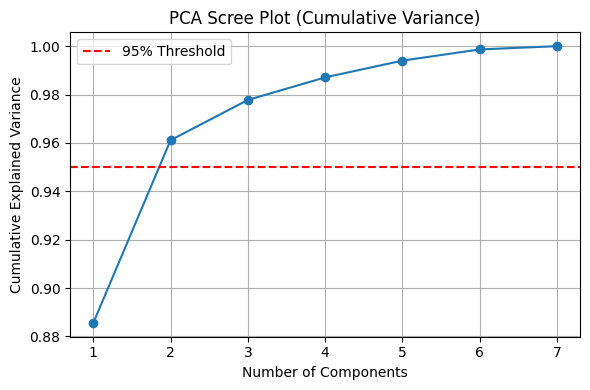

In [ ]:
# Calculate variance explained
explained_var = pca.explained_variance_ratio_
cum_explained = np.cumsum(explained_var)

plt.figure(figsize=(6,4))
plt.plot(range(1, len(explained_var)+1), cum_explained, marker="o")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Scree Plot (Cumulative Variance)")
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Threshold')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
explained_variance = pd.DataFrame({
    "Principal_Component": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
    "Explained_Variance (%)": pca.explained_variance_ratio_ * 100
})

In [ ]:
print(explained_variance)

  Principal_Component  Explained_Variance (%)
0                 PC1               88.559491
1                 PC2                7.553270
2                 PC3                1.662514
3                 PC4                0.933163
4                 PC5                0.692808
5                 PC6                0.462831
6                 PC7                0.135923


In [ ]:
# This table shows how much of the total variability in the data is explained by each principal component.
# PC1 alone explains about 88% of the total variance. This means most of the information in all 7 biomarkers is captured by one component.
# PC2 explains ~7% → small additional variation.
# The remaining components contribute relatively little additional information.

In [ ]:
pca.components_[0]

array([0.39899904, 0.30119668, 0.38484617, 0.38126439, 0.38996626,
       0.39600035, 0.38434524])

In [ ]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=indicators,
    columns=[f'PC{i+1}' for i in range(len(indicators))]
)

In [ ]:
loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
Permeability,0.398999,-0.064128,0.052044,-0.069949,-0.235273,0.101605,0.873733
LDL_uptake,0.301197,0.903799,0.050108,0.255896,0.150041,-0.043056,-0.008299
Total_ROS,0.384846,-0.270564,-0.057806,0.697913,-0.405789,-0.279672,-0.213032
Vascular_Marker,0.381264,-0.152307,0.834243,-0.212202,0.181493,-0.152092,-0.185410
Cell_Signalling,0.389966,0.101164,-0.370523,-0.623712,-0.327535,-0.381263,-0.242379
Tube_formation,0.396000,-0.057797,-0.098761,-0.055392,-0.092166,0.850901,-0.307399
In_vivo_recovery,0.384345,-0.262790,-0.385274,0.073663,0.780228,-0.130695,0.059337


In [ ]:
# The PCA loadings show that PC1 captures a strong common biological signal across all biomarkers,
# while higher components represent smaller, more specific biological variations.
# PC1 doesn't represent one specific biological process; it represents the magnitude of the overall response.
# PC1 loadings are similar because all biomarkers are strongly correlated and reflect a single dominant underlying vascular health factor.

In [ ]:
pc1_loadings = loadings["PC1"]

In [ ]:
pc1_loadings

,PC1
Permeability,0.398999
LDL_uptake,0.301197
Total_ROS,0.384846
Vascular_Marker,0.381264
Cell_Signalling,0.389966
Tube_formation,0.396000
In_vivo_recovery,0.384345


In [ ]:
pc1_loadings = loadings[["PC1"]]
print(pc1_loadings)

                       PC1
Permeability      0.398999
LDL_uptake        0.301197
Total_ROS         0.384846
Vascular_Marker   0.381264
Cell_Signalling   0.389966
Tube_formation    0.396000
In_vivo_recovery  0.384345


In [ ]:
squared_loadings = pc1_loadings ** 2
pca_weights = squared_loadings / squared_loadings.sum()

print(pca_weights)

                       PC1
Permeability      0.159200
LDL_uptake        0.090719
Total_ROS         0.148107
Vascular_Marker   0.145363
Cell_Signalling   0.152074
Tube_formation    0.156816
In_vivo_recovery  0.147721


In [ ]:
health_score_pca = X_scaled @ pca_weights.values
df["Health_Score_PCA_SQ"] = health_score_pca

In [ ]:
df

,Permeability,LDL_uptake,Total_ROS,Vascular_Marker,Cell_Signalling,Tube_formation,In_vivo_recovery,Group,Health_Score_PCA_SQ
0,71,0.30,1.8,68,43,39,35,0,-1.007333
1,68,0.34,1.9,75,47,35,34,0,-0.922699
2,20,1.20,1.0,100,80,100,70,1,0.883129
3,79,0.19,1.8,70,43,41,28,0,-1.078931
4,17,1.30,0.9,96,88,92,72,1,0.925863
5,69,2.00,2.2,74,55,44,19,0,-0.762882
6,22,1.40,1.1,96,85,99,79,1,0.910013
7,23,1.10,0.9,98,78,98,78,1,0.874772
8,70,0.35,2.1,69,59,46,22,0,-0.979523
9,21,1.80,0.8,92,95,96,82,1,1.088714


In [ ]:
# PCA produces scores relative to the average, so values below the average become negative and values above the average become positive.

In [ ]:
df["Health_Score_PCA"] = (
    (df["Health_Score_PCA_SQ"] - df["Health_Score_PCA_SQ"].min()) /
    (df["Health_Score_PCA_SQ"].max() - df["Health_Score_PCA_SQ"].min())
) * 100

In [ ]:
df[["Health_Score_PCA_SQ", "Health_Score_PCA", "Group"]]

,Health_Score_PCA_SQ,Health_Score_PCA,Group
0,-1.007333,3.189803,0
1,-0.922699,6.960316,0
2,0.883129,87.412317,1
3,-1.078931,0.000000,0
4,0.925863,89.316178,1
5,-0.762882,14.080402,0
6,0.910013,88.610027,1
7,0.874772,87.040006,1
8,-0.979523,4.428733,0
9,1.088714,96.571383,1


In [ ]:
df

,Permeability,LDL_uptake,Total_ROS,Vascular_Marker,Cell_Signalling,Tube_formation,In_vivo_recovery,Group,Health_Score_PCA_SQ,Health_Score_PCA
0,71,0.30,1.8,68,43,39,35,0,-1.007333,3.189803
1,68,0.34,1.9,75,47,35,34,0,-0.922699,6.960316
2,20,1.20,1.0,100,80,100,70,1,0.883129,87.412317
3,79,0.19,1.8,70,43,41,28,0,-1.078931,0.000000
4,17,1.30,0.9,96,88,92,72,1,0.925863,89.316178
5,69,2.00,2.2,74,55,44,19,0,-0.762882,14.080402
6,22,1.40,1.1,96,85,99,79,1,0.910013,88.610027
7,23,1.10,0.9,98,78,98,78,1,0.874772,87.040006
8,70,0.35,2.1,69,59,46,22,0,-0.979523,4.428733
9,21,1.80,0.8,92,95,96,82,1,1.088714,96.571383


### b). Without changing the direction of negative indicators

In [ ]:
df

,Permeability,LDL_uptake,Total_ROS,Vascular_Marker,Cell_Signalling,Tube_formation,In_vivo_recovery,Group,Health_Score_PCA_SQ,Health_Score_PCA
0,71,0.30,1.8,68,43,39,35,0,-1.007333,3.189803
1,68,0.34,1.9,75,47,35,34,0,-0.922699,6.960316
2,20,1.20,1.0,100,80,100,70,1,0.883129,87.412317
3,79,0.19,1.8,70,43,41,28,0,-1.078931,0.000000
4,17,1.30,0.9,96,88,92,72,1,0.925863,89.316178
5,69,2.00,2.2,74,55,44,19,0,-0.762882,14.080402
6,22,1.40,1.1,96,85,99,79,1,0.910013,88.610027
7,23,1.10,0.9,98,78,98,78,1,0.874772,87.040006
8,70,0.35,2.1,69,59,46,22,0,-0.979523,4.428733
9,21,1.80,0.8,92,95,96,82,1,1.088714,96.571383


In [ ]:
indicators

Index(['Permeability', 'LDL_uptake', 'Total_ROS', 'Vascular_Marker',
       'Cell_Signalling', 'Tube_formation', 'In_vivo_recovery'],
      dtype='object')

In [ ]:
X = df[indicators]

In [ ]:
X

,Permeability,LDL_uptake,Total_ROS,Vascular_Marker,Cell_Signalling,Tube_formation,In_vivo_recovery
0,71,0.30,1.8,68,43,39,35
1,68,0.34,1.9,75,47,35,34
2,20,1.20,1.0,100,80,100,70
3,79,0.19,1.8,70,43,41,28
4,17,1.30,0.9,96,88,92,72
5,69,2.00,2.2,74,55,44,19
6,22,1.40,1.1,96,85,99,79
7,23,1.10,0.9,98,78,98,78
8,70,0.35,2.1,69,59,46,22
9,21,1.80,0.8,92,95,96,82


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

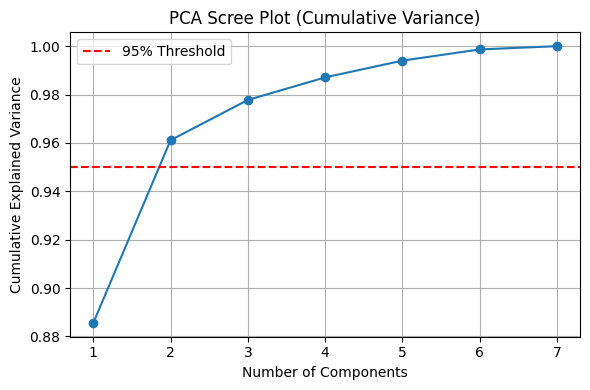

In [ ]:
# Calculate variance explained
explained_var = pca.explained_variance_ratio_
cum_explained = np.cumsum(explained_var)

plt.figure(figsize=(6,4))
plt.plot(range(1, len(explained_var)+1), cum_explained, marker="o")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Scree Plot (Cumulative Variance)")
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Threshold')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
explained_variance = pd.DataFrame({
    "Principal_Component": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
    "Explained_Variance (%)": pca.explained_variance_ratio_ * 100
})

In [ ]:
explained_variance

,Principal_Component,Explained_Variance (%)
0,PC1,88.559491
1,PC2,7.553270
2,PC3,1.662514
3,PC4,0.933163
4,PC5,0.692808
5,PC6,0.462831
6,PC7,0.135923


In [ ]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=indicators,
    columns=[f'PC{i+1}' for i in range(len(indicators))]
)

In [ ]:
loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
Permeability,0.398999,0.064128,-0.052044,-0.069949,0.235273,-0.101605,0.873733
LDL_uptake,-0.301197,0.903799,0.050108,-0.255896,0.150041,-0.043056,0.008299
Total_ROS,0.384846,0.270564,0.057806,0.697913,0.405789,0.279672,-0.213032
Vascular_Marker,-0.381264,-0.152307,0.834243,0.212202,0.181493,-0.152092,0.185410
Cell_Signalling,-0.389966,0.101164,-0.370523,0.623712,-0.327535,-0.381263,0.242379
Tube_formation,-0.396000,-0.057797,-0.098761,0.055392,-0.092166,0.850901,0.307399
In_vivo_recovery,-0.384345,-0.262790,-0.385274,-0.073663,0.780228,-0.130695,-0.059337


In [ ]:
# Changing indicator direction does NOT force PCA to change loadings. Because PCA is unsupervised. It does not know good or bad. It only captures maximum variance.

In [ ]:
pc1_loadings = loadings[["PC1"]]
print(pc1_loadings)

                       PC1
Permeability      0.398999
LDL_uptake       -0.301197
Total_ROS         0.384846
Vascular_Marker  -0.381264
Cell_Signalling  -0.389966
Tube_formation   -0.396000
In_vivo_recovery -0.384345


In [ ]:
squared_loadings = pc1_loadings ** 2
pca_weights = squared_loadings / squared_loadings.sum()

print(pca_weights)

                       PC1
Permeability      0.159200
LDL_uptake        0.090719
Total_ROS         0.148107
Vascular_Marker   0.145363
Cell_Signalling   0.152074
Tube_formation    0.156816
In_vivo_recovery  0.147721


In [ ]:
health_score_pca2 = X_scaled @ pca_weights.values
df["Health_Score_PCA_SQ2"] = health_score_pca2

In [ ]:
df

,Permeability,LDL_uptake,Total_ROS,Vascular_Marker,Cell_Signalling,Tube_formation,In_vivo_recovery,Group,Health_Score_PCA_SQ,Health_Score_PCA,Health_Score_PCA_SQ2
0,71,0.30,1.8,68,43,39,35,0,-1.007333,3.189803,-0.500368
1,68,0.34,1.9,75,47,35,34,0,-0.922699,6.960316,-0.396818
2,20,1.20,1.0,100,80,100,70,1,0.883129,87.412317,0.311318
3,79,0.19,1.8,70,43,41,28,0,-1.078931,0.000000,-0.473040
4,17,1.30,0.9,96,88,92,72,1,0.925863,89.316178,0.260939
5,69,2.00,2.2,74,55,44,19,0,-0.762882,14.080402,-0.056590
6,22,1.40,1.1,96,85,99,79,1,0.910013,88.610027,0.418948
7,23,1.10,0.9,98,78,98,78,1,0.874772,87.040006,0.284043
8,70,0.35,2.1,69,59,46,22,0,-0.979523,4.428733,-0.316881
9,21,1.80,0.8,92,95,96,82,1,1.088714,96.571383,0.417239


In [ ]:
df["Health_Score_PCA2"] = (
    (df["Health_Score_PCA_SQ2"] - df["Health_Score_PCA_SQ2"].min()) /
    (df["Health_Score_PCA_SQ2"].max() - df["Health_Score_PCA_SQ2"].min())
) * 100

In [ ]:
df

,Permeability,LDL_uptake,Total_ROS,Vascular_Marker,Cell_Signalling,Tube_formation,In_vivo_recovery,Group,Health_Score_PCA_SQ,Health_Score_PCA,Health_Score_PCA_SQ2,Health_Score_PCA2
0,71,0.30,1.8,68,43,39,35,0,-1.007333,3.189803,-0.500368,0.000000
1,68,0.34,1.9,75,47,35,34,0,-0.922699,6.960316,-0.396818,11.263840
2,20,1.20,1.0,100,80,100,70,1,0.883129,87.412317,0.311318,88.292352
3,79,0.19,1.8,70,43,41,28,0,-1.078931,0.000000,-0.473040,2.972674
4,17,1.30,0.9,96,88,92,72,1,0.925863,89.316178,0.260939,82.812396
5,69,2.00,2.2,74,55,44,19,0,-0.762882,14.080402,-0.056590,48.272636
6,22,1.40,1.1,96,85,99,79,1,0.910013,88.610027,0.418948,100.000000
7,23,1.10,0.9,98,78,98,78,1,0.874772,87.040006,0.284043,85.325567
8,70,0.35,2.1,69,59,46,22,0,-0.979523,4.428733,-0.316881,19.959129
9,21,1.80,0.8,92,95,96,82,1,1.088714,96.571383,0.417239,99.814076


In [ ]:
# After aligning indicators, the PCA health score clearly represents overall vascular health.
# -> Higher score → better health
# -> Lower score → poorer health
# This score is:
# -> Easy to interpret
# -> Biologically meaningful
# -> Consistent with group labels
# Both PCA approaches capture the same underlying health signal. However, aligning indicators ensures that
# higher PCA scores consistently represent better vascular health, making PCA1 more interpretable and suitable as a health score.
# The second approach gives low values because PCA combines biomarkers with opposite biological meanings,
# causing positive and negative effects to cancel each other.

# Linear Regression Model

In [ ]:
df

,Permeability,LDL_uptake,Total_ROS,Vascular_Marker,Cell_Signalling,Tube_formation,In_vivo_recovery,Group,Health_Score_EW
0,71,1.40,1.8,68,43,39,35,0,21.528020
1,68,1.80,1.9,75,47,35,34,0,27.743127
2,20,0.30,1.0,100,80,100,70,1,72.180578
3,79,1.30,1.8,70,43,41,28,0,18.392972
4,17,0.19,0.9,96,88,92,72,1,73.251620
5,69,1.10,2.2,74,55,44,19,0,18.794898
6,22,0.30,1.1,96,85,99,79,1,72.177193
7,23,2.00,0.9,98,78,98,78,1,87.914510
8,70,1.70,2.1,69,59,46,22,0,25.571916
9,21,0.34,0.8,92,95,96,82,1,77.978252


In [ ]:
df = df.drop(columns=["Group"])

In [ ]:
df

,Permeability,LDL_uptake,Total_ROS,Vascular_Marker,Cell_Signalling,Tube_formation,In_vivo_recovery,Health_Score_EW
0,71,1.40,1.8,68,43,39,35,21.528020
1,68,1.80,1.9,75,47,35,34,27.743127
2,20,0.30,1.0,100,80,100,70,72.180578
3,79,1.30,1.8,70,43,41,28,18.392972
4,17,0.19,0.9,96,88,92,72,73.251620
5,69,1.10,2.2,74,55,44,19,18.794898
6,22,0.30,1.1,96,85,99,79,72.177193
7,23,2.00,0.9,98,78,98,78,87.914510
8,70,1.70,2.1,69,59,46,22,25.571916
9,21,0.34,0.8,92,95,96,82,77.978252


In [ ]:
df.describe()

,Permeability,LDL_uptake,Total_ROS,Vascular_Marker,Cell_Signalling,Tube_formation,In_vivo_recovery,Health_Score_EW
count,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000
mean,45.857143,0.957143,1.450000,84.714286,68.071429,67.785714,52.142857,49.207265
std,26.720367,0.653210,0.548775,12.418526,20.200778,29.571760,25.806550,28.327371
min,13.000000,0.190000,0.700000,68.000000,43.000000,32.000000,19.000000,18.392972
25%,21.250000,0.310000,0.925000,74.250000,49.250000,40.250000,29.000000,21.991332
50%,47.000000,1.150000,1.500000,85.500000,68.500000,68.000000,52.500000,47.616254
75%,69.750000,1.375000,1.900000,96.000000,87.250000,96.750000,76.500000,72.983859
max,79.000000,2.000000,2.200000,100.000000,95.000000,100.000000,83.000000,87.914510


In [ ]:
X = df.drop(columns=["Health_Score_EW"])
y = df["Health_Score_EW"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.28, random_state=42)

In [ ]:
y_test

,Health_Score_EW
9,77.978252
11,21.226418
0,21.528020
12,67.489381


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [ ]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled, columns=X.columns)

In [ ]:
X_train_scaled

,Permeability,LDL_uptake,Total_ROS,Vascular_Marker,Cell_Signalling,Tube_formation,In_vivo_recovery
0,0.926965,0.115592,1.368167,-0.902273,-0.715780,-0.893774,-1.251206
1,0.965269,1.028163,1.185744,-1.294566,-0.490337,-0.822840,-1.129335
2,-0.949948,-1.101169,-0.820900,1.137649,0.693236,1.092391,0.820596
3,0.888661,1.180259,0.820900,-0.823815,-1.166665,-1.212980,-0.641852
4,-1.218078,-1.025121,-1.368167,1.137649,1.369563,0.985989,0.861220
5,-1.064861,-1.268474,-1.003322,0.823815,1.144121,0.808653,0.901843
6,-0.835035,1.484449,-1.003322,0.980732,0.580514,1.021456,1.145585
7,0.850356,0.267687,0.820900,-0.666897,-0.997583,-1.035643,-1.007464
8,1.310008,0.419783,0.638478,-1.216107,-1.392107,-1.000176,-0.885594
9,-0.873339,-1.101169,-0.638478,0.823815,0.975039,1.056924,1.186208


In [ ]:
X_test_scaled

,Permeability,LDL_uptake,Total_ROS,Vascular_Marker,Cell_Signalling,Tube_formation,In_vivo_recovery
0,-0.911643,-1.040331,-1.185744,0.509980,1.538645,0.950522,1.308079
1,1.156791,0.267687,1.003322,-0.353063,-1.053944,-1.319381,-0.723099
2,1.003574,0.571878,0.638478,-1.373024,-1.392107,-1.071111,-0.601229
3,-0.681817,-1.222845,-0.456056,0.353063,1.200481,0.737719,1.348702


In [ ]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

LinearRegression()

In [ ]:
y_train_pred = lr.predict(X_train_scaled)
y_test_pred  = lr.predict(X_test_scaled)

In [ ]:
print("TRAIN PERFORMANCE")
print("R²:", r2_score(y_train, y_train_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))

print("\nTEST PERFORMANCE")
print("R²:", r2_score(y_test, y_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))

TRAIN PERFORMANCE
R²: 1.0
RMSE: 1.5114698744996706e-14

TEST PERFORMANCE
R²: 1.0
RMSE: 2.8532515735351556e-14


In [ ]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_
}).sort_values(by="Coefficient", ascending=False)

In [ ]:
coef_df

,Feature,Standardized_Coefficient
1,LDL_uptake,6.054172
4,Cell_Signalling,5.686822
5,Tube_formation,4.607032
3,Vascular_Marker,4.425551
6,In_vivo_recovery,4.273655
2,Total_ROS,-6.090876
0,Permeability,-6.592602


In [ ]:
# Our health score model shows that vascular permeability and oxidative stress are the dominant drivers of poor vascular health,
# while LDL uptake, signaling integrity, and angiogenic capacity are the strongest protective factors.

In [ ]:
# Generating Synthetic Data using Random Sampling from Normal Distribution

#np.random.seed(42)
#
#n_new = 500   # generate 50 synthetic samples per group
#
#features = df.columns[:-1]
#
#df_good = df[df["Group"] == 1][features]
#df_bad  = df[df["Group"] == 0][features]
#
#synthetic_good = pd.DataFrame()
#synthetic_bad  = pd.DataFrame()
#
#for col in features:
#    mu_g, sigma_g = df_good[col].mean(), df_good[col].std()
#    mu_b, sigma_b = df_bad[col].mean(), df_bad[col].std()
#
#    synthetic_good[col] = np.random.normal(mu_g, sigma_g, n_new)
#    synthetic_bad[col]  = np.random.normal(mu_b, sigma_b, n_new)
#
#synthetic_good["Group"] = 1
#synthetic_bad["Group"]  = 0
#
#df_synthetic = pd.concat([synthetic_good, synthetic_bad], ignore_index=True)

In [ ]:
df

,Permeability,LDL_uptake,Total_ROS,Vascular_Marker,Cell_Signalling,Tube_formation,In_vivo_recovery,Group,Anomaly_Z,Anomaly_IQR,Anomaly_IF
0,71,0.30,1.8,68,43,39,35,0,0,0,0
1,68,0.34,1.9,75,47,35,34,0,0,0,0
2,20,1.20,1.0,100,80,100,70,1,0,0,0
3,79,0.19,1.8,70,43,41,28,0,0,0,0
4,17,1.30,0.9,96,88,92,72,1,0,0,0
5,69,2.00,2.2,74,55,44,19,0,0,0,1
6,22,1.40,1.1,96,85,99,79,1,0,0,0
7,23,1.10,0.9,98,78,98,78,1,0,0,0
8,70,0.35,2.1,69,59,46,22,0,0,0,0
9,21,1.80,0.8,92,95,96,82,1,0,0,0


#### Generating Synthetic Data Using Bootstrap Sampling
#### Bootstrap sampling is used to generate synthetic data by randomly resampling the original dataset with replacement. This method preserves the original data distribution while increasing the dataset size for reliable statistical analysis and machine learning model training.

In [ ]:
# Remove Extra Columns
df = df.drop(columns=["Anomaly_Z", "Anomaly_IQR", "Anomaly_IF"])

# Separate the groups to ensure balance
group1 = df[df['Group'] == 1]
group0 = df[df['Group'] == 0]

# Bootstrap Resample (Sample with Replacement)
# We sample 500 items from Group 1, and 500 from Group 0
boot_g1 = group1.sample(n=500, replace=True, random_state=42)
boot_g0 = group0.sample(n=500, replace=True, random_state=42)

# Combine
df_bootstrapped = pd.concat([boot_g1, boot_g0])

# Shuffle the rows
df_bootstrapped = df_bootstrapped.sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
df_bootstrapped.shape

(1000, 8)

In [ ]:
df_bootstrapped.head(10)

,Permeability,LDL_uptake,Total_ROS,Vascular_Marker,Cell_Signalling,Tube_formation,In_vivo_recovery,Group
0,67,0.30,1.9,77,50,40,25,0
1,69,2.00,2.2,74,55,44,19,0
2,67,0.30,1.9,77,50,40,25,0
3,71,0.30,1.8,68,43,39,35,0
4,21,1.80,0.8,92,95,96,82,1
5,71,0.30,1.8,68,43,39,35,0
6,75,0.22,2.0,81,49,32,32,0
7,70,0.35,2.1,69,59,46,22,0
8,68,0.34,1.9,75,47,35,34,0
9,13,1.70,0.7,100,92,97,71,1


In [ ]:
df_bootstrapped.tail(10)

,Permeability,LDL_uptake,Total_ROS,Vascular_Marker,Cell_Signalling,Tube_formation,In_vivo_recovery,Group
990,20,1.2,1.0,100,80,100,70,1
991,69,2.0,2.2,74,55,44,19,0
992,27,1.2,1.2,90,89,90,83,1
993,67,0.3,1.9,77,50,40,25,0
994,13,1.7,0.7,100,92,97,71,1
995,21,1.8,0.8,92,95,96,82,1
996,21,1.8,0.8,92,95,96,82,1
997,67,0.3,1.9,77,50,40,25,0
998,20,1.2,1.0,100,80,100,70,1
999,23,1.1,0.9,98,78,98,78,1


In [ ]:
df_bootstrapped.describe()

,Permeability,LDL_uptake,Total_ROS,Vascular_Marker,Cell_Signalling,Tube_formation,In_vivo_recovery,Group
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,45.911000,0.963840,1.452100,84.842000,67.674000,67.843000,52.068000,0.50000
std,25.724868,0.628296,0.526339,12.061447,19.308302,28.603225,24.794074,0.50025
min,13.000000,0.190000,0.700000,68.000000,43.000000,32.000000,19.000000,0.00000
25%,21.000000,0.300000,0.900000,74.000000,49.000000,40.000000,28.000000,0.00000
50%,47.000000,1.150000,1.500000,85.500000,68.500000,68.000000,52.500000,0.50000
75%,70.000000,1.400000,1.900000,96.000000,88.000000,97.000000,78.000000,1.00000
max,79.000000,2.000000,2.200000,100.000000,95.000000,100.000000,83.000000,1.00000


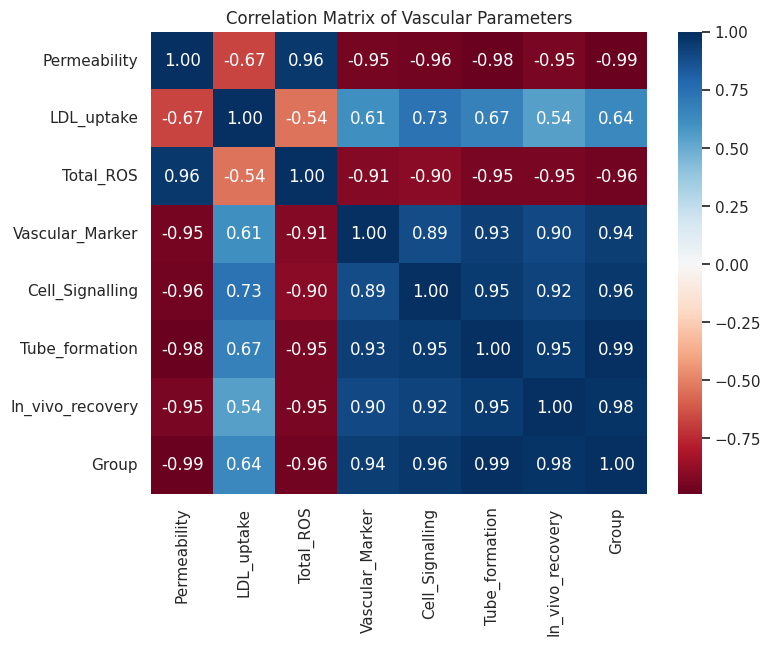

In [ ]:
corr_matrix = df_bootstrapped.corr()

# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu", center=0)
plt.title("Correlation Matrix of Vascular Parameters")
plt.show()

In [ ]:
features = df_bootstrapped.drop(columns=["Group"])

vif_data = pd.DataFrame()
vif_data["Feature"] = features.columns # Store Feature Names

vif_values = []

number_of_features = features.shape[1]

# Calculate VIF for Each Feature (One by One)
for i in range(number_of_features):
    feature_matrix = features.values
    vif_value = variance_inflation_factor(feature_matrix, i) # Calculate VIF for the i-th feature
    vif_values.append(vif_value)

vif_data["VIF"] = vif_values

vif_data_sorted = vif_data.sort_values(by="VIF", ascending=False)

In [ ]:
vif_data_sorted

,Feature,VIF
3,Vascular_Marker,229.850178
4,Cell_Signalling,196.755916
5,Tube_formation,183.680237
2,Total_ROS,162.103351
0,Permeability,111.216740
6,In_vivo_recovery,83.224881
1,LDL_uptake,10.632943


In [ ]:
X = df_bootstrapped.drop('Group', axis=1)
y = df_bootstrapped['Group']

In [ ]:
X

,Permeability,LDL_uptake,Total_ROS,Vascular_Marker,Cell_Signalling,Tube_formation,In_vivo_recovery
0,67,0.3,1.9,77,50,40,25
1,69,2.0,2.2,74,55,44,19
2,67,0.3,1.9,77,50,40,25
3,71,0.3,1.8,68,43,39,35
4,21,1.8,0.8,92,95,96,82
...,...,...,...,...,...,...,...
995,21,1.8,0.8,92,95,96,82
996,21,1.8,0.8,92,95,96,82
997,67,0.3,1.9,77,50,40,25
998,20,1.2,1.0,100,80,100,70


In [ ]:
y

,Group
0,0
1,0
2,0
3,0
4,1
...,...
995,1
996,1
997,0
998,1


In [ ]:
# Scale the Data (Standardization)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((750, 7), (250, 7), (750,), (250,))

In [ ]:
# Fitting Logistic Regression Model
model = LogisticRegression(penalty='l2', solver="newton-cholesky" , C=1.0, max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, solver='newton-cholesky')

In [ ]:
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 1.0
Confusion Matrix:
 [[121   0]
 [  0 129]]


In [ ]:
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       121
           1       1.00      1.00      1.00       129

    accuracy                           1.00       250
   macro avg       1.00      1.00      1.00       250
weighted avg       1.00      1.00      1.00       250



In [ ]:
# View the Coefficients ("Weights")
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

coefficients

,Feature,Coefficient
6,In_vivo_recovery,1.221830
5,Tube_formation,1.126216
4,Cell_Signalling,1.050529
3,Vascular_Marker,0.995814
1,LDL_uptake,0.426208
2,Total_ROS,-1.071409
0,Permeability,-1.083433


In [ ]:
# Training SVM Model
svm_model = SVC(kernel="rbf", C=1.0, gamma="scale", probability=True)
svm_model.fit(X_train, y_train)

SVC(probability=True)

In [ ]:
y_pred = svm_model.predict(X_test)
y_prob = svm_model.predict_proba(X_test)[:, 1]   # Probabilities for ROC
print("SVM Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

SVM Accuracy: 1.0
Confusion Matrix:
 [[121   0]
 [  0 129]]


In [ ]:
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       121
           1       1.00      1.00      1.00       129

    accuracy                           1.00       250
   macro avg       1.00      1.00      1.00       250
weighted avg       1.00      1.00      1.00       250



In [ ]:
# Compute ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc_score)

AUC Score: 1.0


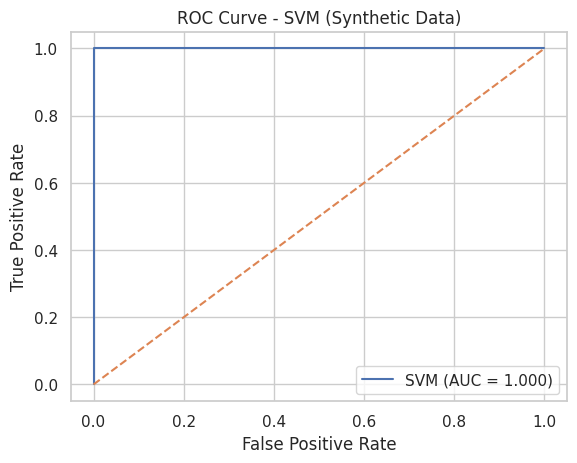

In [ ]:
# Plot ROC
plt.figure()
plt.plot(fpr, tpr, label=f"SVM (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")   # random classifier line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM (Synthetic Data)")
plt.legend()
plt.grid(True)
plt.show()

# **Anomly Detection**
#### Z-Score Method: It assumes the data follows a normal distribution. And marks values that are more than 3 standard deviations away from the mean.

### IQR Method: In this values below Q1 - 1.5 x IQR  or above Q3 + 1.5 x IQR are treated as outliers.

In [ ]:
features = df_bootstrapped.drop(columns=["Group"])

In [ ]:
# Z-Score Outlier Detection
z_scores = np.abs(stats.zscore(features))
df_bootstrapped["Anomaly_Z"] = (z_scores > 3).any(axis=1).astype(int)
anomalies_Z = df_bootstrapped[df_bootstrapped["Anomaly_Z"] == 1]

In [ ]:
anomalies_Z

,Permeability,LDL_uptake,Total_ROS,Vascular_Marker,Cell_Signalling,Tube_formation,In_vivo_recovery,Group,Anomaly_Z


In [ ]:
pd.crosstab(df_bootstrapped["Group"], df_bootstrapped["Anomaly_Z"])

Anomaly_Z,0
Group,
0,500
1,500


In [ ]:
# IQR Outlier Detection
Q1 = features.quantile(0.25)
Q3 = features.quantile(0.75)

IQR = Q3 - Q1

In [ ]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [ ]:
iqr_outliers = ((features < lower_bound) | (features > upper_bound))
df_bootstrapped["Anomaly_IQR"] = iqr_outliers.any(axis=1).astype(int)
anomalies_IQR = df_bootstrapped[df_bootstrapped["Anomaly_IQR"] == 1]

In [ ]:
anomalies_IQR

,Permeability,LDL_uptake,Total_ROS,Vascular_Marker,Cell_Signalling,Tube_formation,In_vivo_recovery,Group,Anomaly_Z,Anomaly_IQR


In [ ]:
pd.crosstab(df_bootstrapped["Group"], df_bootstrapped["Anomaly_IQR"])

Anomaly_IQR,0
Group,
0,500
1,500


In [ ]:
iqr_outliers.sum()

,0
Permeability,0
LDL_uptake,0
Total_ROS,0
Vascular_Marker,0
Cell_Signalling,0
Tube_formation,0
In_vivo_recovery,0


In [ ]:
X

,Permeability,LDL_uptake,Total_ROS,Vascular_Marker,Cell_Signalling,Tube_formation,In_vivo_recovery
0,67,0.3,1.9,77,50,40,25
1,69,2.0,2.2,74,55,44,19
2,67,0.3,1.9,77,50,40,25
3,71,0.3,1.8,68,43,39,35
4,21,1.8,0.8,92,95,96,82
...,...,...,...,...,...,...,...
995,21,1.8,0.8,92,95,96,82
996,21,1.8,0.8,92,95,96,82
997,67,0.3,1.9,77,50,40,25
998,20,1.2,1.0,100,80,100,70


In [ ]:
# Isolation Forest
iso = IsolationForest(n_estimators=200, contamination=0.05, random_state=42)

In [ ]:
df_bootstrapped["Anomaly_IF"] = iso.fit_predict(X_scaled)

In [ ]:
df_bootstrapped["Anomaly_IF"].value_counts()

,count
Anomaly_IF,
1,1000


In [ ]:
df_bootstrapped["Anomaly_IF"] = df_bootstrapped["Anomaly_IF"].map({1: 0, -1: 1})

In [ ]:
anomalies_IF = df_bootstrapped[df_bootstrapped["Anomaly_IF"] == 1]

In [ ]:
anomalies_IF

,Permeability,LDL_uptake,Total_ROS,Vascular_Marker,Cell_Signalling,Tube_formation,In_vivo_recovery,Group,Anomaly_Z,Anomaly_IQR,Anomaly_IF


In [ ]:
pd.crosstab(df_bootstrapped["Group"], df_bootstrapped["Anomaly_IF"])

Anomaly_IF,0
Group,
0,500
1,500
